---
title: "🗓️ Week 4 - Classification Recap, Resampling & Fairness"
subtitle: "Theme: Supervised Learning"
author: "Dr. Ghita Berrada"
date: "09 February 2025"
format: 
  html:
    from: markdown+emoji
    page-layout: full
    toc: true
    toc-depth: 2
self-contained: true
---

Welcome to Week 4! This week, we complete our introduction to classification, explore advanced evaluation metrics, introduce multi-class classification and K-NN, learn resampling methods, and discuss algorithmic fairness—all using the COMPAS recidivism dataset.

# Part 1: The COMPAS Dataset & Data Preprocessing

## 1.1 What is COMPAS?

**COMPAS** (Correctional Offender Management Profiling for Alternative Sanctions) is a commercial algorithm developed by Northpointe (now Equivant) to predict recidivism risk. It is used by courts in the United States to inform bail, sentencing, and parole decisions.

**Key features:**

* Predicts whether a defendant will reoffend within two years
* Outputs a risk category: Low, Medium, or High
* Based on ~130 questions covering criminal history, demographics, and social factors
* Proprietary algorithm (exact method is not public)

## 1.2 The ProPublica Investigation

In 2016, ProPublica analyzed COMPAS scores for over 7,000 defendants in Broward County, Florida. They found:

* *Black defendants were twice as likely to be misclassified as high risk* compared to white defendants
* *White defendants were more likely to be misclassified as low risk* when they actually reoffended
* These disparities persisted even when controlling for criminal history

This sparked a major debate about algorithmic fairness in criminal justice.

## 1.3 Dataset Overview

**Source:** ProPublica's GitHub (https://github.com/propublica/compas-analysis)

**Sample:** 7,214 defendants in Broward County, 2013-2014, with two-year recidivism outcomes

**Key variables:**

* **Outcome:** `two_year_recid` (0/1 — did the person reoffend within 2 years?)
* **Risk scores:** `decile_score` (1-10), `score_text` (Low/Medium/High)
* **Demographics:** `age`, `sex`, `race`
* **Criminal history:** `priors_count`, `c_charge_degree` (felony/misdemeanor)

## 1.4 Loading and Exploring the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             balanced_accuracy_score)
from sklearn.calibration import calibration_curve
import warnings
import missingno as msno
warnings.filterwarnings('ignore')

np.random.seed(42)




In [2]:
# Load the data
compas = pd.read_csv('../data/compas-scores-two-years.csv')

print(f"Dataset shape: {compas.shape}")
compas.head()

Dataset shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


### 1.4.1 COMPAS Dataset Variables

The dataset contains detailed information about defendants, COMPAS scores, and recidivism outcomes. Here's a comprehensive guide to the variables:

#### How to read this table

* **✓ / ✓✓** indicate variables used for modelling or outcomes
* **⚠️ Sensitive attribute** = protected characteristic (raises fairness concerns)
* **🚨 Proxy risk** = not protected itself, but may encode structural bias
* **❌ Excluded from modelling** = not appropriate as predictors

**Key:**

* ✓ = Useful for modelling
* ✓✓ = Primary outcome variable
* ⚠️ = Sensitive / protected attribute
* 🚨 = Potential proxy for protected attributes


#### 🆔 ID Variables (Excluded)

| Variable | Description                 | Analysis | Ethics      |
| -------- | --------------------------- | -------- | ----------- |
| `id`     | Unique defendant identifier | ❌        | Identifiers |
| `name`   | Full name                   | ❌        | Identifiers |
| `first`  | First name                  | ❌        | Identifiers |
| `last`   | Last name                   | ❌        | Identifiers |

> These variables uniquely identify individuals and have **no legitimate predictive role**. Including them would be meaningless and unethical.


#### 👤 Demographics

| Variable  | Description                              | Analysis | Ethics                     |
| --------- | ---------------------------------------- | -------- | -------------------------- |
| `sex`     | Male or Female                           | ✓        | ⚠️ Sensitive attribute     |
| `dob`     | Date of birth                            | ❌        | ⚠️ Sensitive attribute     |
| `age`     | Age at time of screening                 | ✓        | ⚠️ Sensitive attribute     |
| `age_cat` | Age category (e.g. “25–45”)              | ❌        | ⚠️ Sensitive attribute     |
| `race`    | Race (African-American, Caucasian, etc.) | ❌        | ⚠️ **Protected attribute** |

> **Important:**
>
> * We **measure and analyse** race to evaluate fairness
> * We **do not use race as a predictor** (ethical modelling choice)


#### 📈 COMPAS Risk Scores

| Variable         | Description                 | Analysis | Ethics                     |
| ---------------- | --------------------------- | -------- | -------------------------- |
| `decile_score`   | COMPAS risk score (1–10)    | ✓        | 🚨 Encodes historical bias |
| `decile_score.1` | Duplicate of `decile_score` | ❌        | —                          |
| `score_text`     | Low / Medium / High risk    | ✓        | 🚨 Encodes historical bias |

> These scores are **outputs of a proprietary system** (the COMPAS system), not neutral ground truth.
> We treat them as *objects of critique*, not as unquestioned labels.

#### 📜 Criminal History

| Variable          | Description                      | Analysis | Ethics        |
| ----------------- | -------------------------------- | -------- | ------------- |
| `priors_count`    | Number of prior criminal charges | ✓        | 🚨 Proxy risk |
| `priors_count.1`  | Duplicate of `priors_count`      | ❌        | —             |
| `juv_fel_count`   | Prior juvenile felonies          | ❌        | 🚨 Proxy risk |
| `juv_misd_count`  | Prior juvenile misdemeanors      | ❌        | 🚨 Proxy risk |
| `juv_other_count` | Other juvenile offenses          | ❌        | 🚨 Proxy risk |

> Prior records reflect **policing and charging practices**, not just behaviour.
> This makes them *powerful predictors* — but ethically fraught ones.

#### ⚖️ Current Charge Information

| Variable          | Description           | Analysis | Ethics            |
| ----------------- | --------------------- | -------- | ----------------- |
| `c_charge_degree` | Felony or misdemeanor | ✓        | 🚨 Proxy risk     |
| `c_charge_desc`   | Charge description    | ❌        | High leakage risk |
| `c_offense_date`  | Date of offense       | ❌        | —                 |
| `c_arrest_date`   | Arrest date           | ❌        | —                 |

#### 🔁 Recidivism Outcomes

| Variable         | Description               | Analysis | Ethics                 |
| ---------------- | ------------------------- | -------- | ---------------------- |
| `is_recid`       | Any recidivism            | ❌        | Outcome definition     |
| `two_year_recid` | Recidivism within 2 years | ✓✓       | ⚠️ **Target variable** |

> ⚠️ **Crucial reminder:**
> Recidivism ≠ criminality.
> It measures **re-arrest**, which itself is socially and institutionally mediated.


:::callout-note

## Why We Focus on These Variables (and Not the Others)

### Modelling is a normative choice, not just a technical one

The variables marked for analysis (`✓`) are selected because they balance:

1. **Predictive relevance**
2. **Interpretability**
3. **Ethical defensibility**

Many variables in the dataset are excluded *on purpose*, not because they are useless, but because they are **inappropriate**.

### 1️⃣ Why not use identifiers, dates, or case numbers?

Variables like names, IDs, and timestamps:

* Do not generalise
* Do not reflect individual risk
* Invite leakage or spurious correlations

They are excluded to ensure **valid inference** and **ethical restraint**.

### 2️⃣ Why include age, priors, and charge severity?

These variables:

* Have strong empirical association with recidivism
* Are commonly used in real-world risk tools (including COMPAS)
* Are interpretable and auditable

However, they are **not neutral** — especially prior counts, which reflect **policing intensity**, not just behaviour.

This is why we later examine **error rates by race**, even when race is not used as a predictor.

### 3️⃣ Why *not* include race as a predictor?

This is a **deliberate ethical decision**.

Including race would:

* Encode historical discrimination directly into predictions
* Risk legitimising differential treatment by race
* Obscure structural bias behind “statistical accuracy”

Instead, race is used **only for evaluation**, allowing us to ask:

> *Do equally similar individuals receive different error rates depending on race?*

This distinction is foundational to modern fairness analysis.

### 4️⃣ Why focus on `two_year_recid` as the outcome?

The two-year window:

* Matches the COMPAS design
* Is widely used in policy discussions
* Allows direct comparison with ProPublica’s analysis

But it is not ground truth — it reflects **institutional response**, not intrinsic risk.

This is why later sections explicitly discuss **measurement bias** and **fairness trade-offs**.

### Takeaway

> **Feature selection is not just about accuracy.**
> It encodes values, assumptions, and power.

Every variable we include — or exclude — reflects a judgment about:

* What counts as “risk”
* What kinds of errors are acceptable
* Whose interests are prioritised

This is why technical evaluation (AUC, F1, calibration - we'll see what these metrics mean later in the lecture) must always be paired with **ethical scrutiny**.

:::

**Most Important Variables for Our Analysis:**

- **Outcome:** `two_year_recid` (did defendant reoffend within 2 years?)
- **COMPAS Scores:** `decile_score` (1-10), `score_text` (Low/Medium/High)
- **Demographics:** `age`, `sex`, `race`
- **Criminal History:** `priors_count` (number of prior charges)
- **Current Charge:** `c_charge_degree` (felony vs. misdemeanor)

## 1.5 Exploring the Data

In [3]:
# Outcome distribution
outcome_counts = compas['two_year_recid'].value_counts().sort_index()
recid_rate = compas['two_year_recid'].mean()

fig_outcome = go.Figure(data=[
    go.Bar(
        x=['No Recidivism', 'Recidivism'],
        y=outcome_counts.values,
        text=outcome_counts.values,
        textposition='auto',
        marker_color=['#2ecc71', '#e74c3c']
    )
])

fig_outcome.update_layout(
    title=f'Two-Year Recidivism Distribution<br><sub>Overall Recidivism Rate: {recid_rate:.1%}</sub>',
    xaxis_title='Outcome',
    yaxis_title='Number of Defendants',
    template='plotly_white',
    height=400
)

fig_outcome.show()

# Race distribution
race_counts = compas['race'].value_counts()

fig_race = go.Figure(data=[
    go.Bar(
        x=race_counts.index,
        y=race_counts.values,
        text=race_counts.values,
        textposition='auto',
        marker_color='#3498db'
    )
])

fig_race.update_layout(
    title='Race Distribution in COMPAS Dataset',
    xaxis_title='Race',
    yaxis_title='Number of Defendants',
    template='plotly_white',
    height=400,
    xaxis={'categoryorder': 'total descending'}
)

fig_race.show()

# Combined visualization: Recidivism by Race
recid_by_race = pd.crosstab(compas['race'], compas['two_year_recid'], normalize='index') * 100

fig_combined = go.Figure()

fig_combined.add_trace(go.Bar(
    name='No Recidivism',
    x=recid_by_race.index,
    y=recid_by_race[0],
    marker_color='#2ecc71'
))

fig_combined.add_trace(go.Bar(
    name='Recidivism',
    x=recid_by_race.index,
    y=recid_by_race[1],
    marker_color='#e74c3c'
))

fig_combined.update_layout(
    title='Recidivism Rates by Race (%)',
    xaxis_title='Race',
    yaxis_title='Percentage',
    barmode='stack',
    template='plotly_white',
    height=400,
    xaxis={'categoryorder': 'total descending'}
)

fig_combined.show()

### What do these plots tell us?

#### Overall recidivism and class imbalance

The first plot shows the distribution of the two possible outcomes: recidivism and no recidivism within two years. While both outcomes occur frequently, they do **not occur in equal proportions**.

This means that the outcome variable exhibits **class imbalance**, in the sense that one outcome (“no recidivism”) is more common than the other (“recidivism”). At this stage, we simply note this as a basic descriptive feature of the data, without yet considering how it affects modelling and evaluation down the line.

#### Composition of the dataset

The second plot shows that the COMPAS dataset is unevenly distributed across racial groups. African-American and Caucasian defendants account for most observations, while other groups appear far less frequently.

This composition reflects **who enters the COMPAS dataset**, rather than the population at large. The data include only individuals who come into contact with the criminal justice system and are assessed using COMPAS. As a result, the composition of the dataset is shaped by several upstream factors, including:

* **Patterns of arrest and charging:**
  Only individuals who are arrested and formally charged appear in the data. Differences in who is stopped, arrested, or charged—regardless of eventual guilt—directly affect who becomes observable in the dataset.

* **Enforcement and policing practices:**
  Policing intensity, surveillance strategies, and discretionary enforcement vary across neighbourhoods and jurisdictions. These practices influence which individuals are more likely to be encountered by law enforcement and thus represented in administrative criminal justice data.

* **Geographic and institutional context:**
  COMPAS is used in specific courts and counties, not uniformly across all regions. The demographic composition of those jurisdictions, along with local legal practices and policies, shapes the pool of individuals assessed by the tool.

Taken together, these factors mean that the dataset reflects **institutional contact with the criminal justice system**, rather than a neutral or random sample of individuals.

**Why this composition may be problematic**

Such a composition pattern matters because the dataset does not simply record outcomes—it records outcomes **conditional on prior institutional processes**. Groups that are more frequently subject to arrest, charging, or court processing will naturally be over-represented, while others may be under-represented or observed only in specific circumstances.

This raises an important concern: patterns visible in the data may reflect **how the system operates**, as much as—or more than—differences in individual behaviour. At this stage, we do not attempt to resolve this issue, but we note that the data must be interpreted with this context in mind.

#### Differences in observed outcomes across groups

The third plot shows that recidivism rates differ across racial groups, when measured as proportions within each group. These are **observed re-arrest outcomes**, not explanations.

At this stage, we do not attempt to explain these differences or attribute them to specific causes. However, several broad hypotheses are consistent with the patterns shown, including:

* differences in exposure to policing and surveillance after release,
* differences in socio-economic conditions that affect re-arrest likelihood,
* differences in institutional responses to similar behaviour across groups.

These hypotheses are **not tested here**. They simply acknowledge that observed outcome differences can arise from multiple mechanisms, many of which operate outside individual control.

For now, we restrict ourselves to the empirical observation that **outcome distributions are not identical across groups in the dataset**.

### How to read these plots at this stage

Taken together, these plots establish three descriptive facts:

1. The outcome of interest exhibits **class imbalance**
2. The dataset is unevenly distributed across groups
3. Observed outcome proportions differ across those groups

These observations provide necessary context for the analysis that follows. At this point, they are treated as **empirical features of the data**, not as conclusions about causes, performance, or appropriateness of any particular modelling approach.

## 1.6 Data Preprocessing

### Filtering the dataset

We prepare the data for modelling by restricting attention to African-American and Caucasian defendants. These two groups account for the majority of observations in the dataset, which allows group-level comparisons to be made using sufficiently large and well-supported samples. This choice also provides a clear basis for later examining differences in model behaviour across groups.

In [4]:
# Filter to Black and White defendants only
compas_filtered = compas[compas['race'].isin(['African-American', 'Caucasian'])].copy()

print(f"After filtering: {compas_filtered.shape[0]} observations")
print(f"Race distribution:")
print(compas_filtered['race'].value_counts())

After filtering: 6150 observations
Race distribution:
race
African-American    3696
Caucasian           2454
Name: count, dtype: int64


### Selecting variables for analysis

Next, we define the set of variables used in the analysis. These include demographic information, criminal history, charge severity, COMPAS scores, and the recidivism outcome.

At this stage, we do not modify the data; we only select the relevant columns.

In [5]:
# Select features and outcome
feature_cols = ['age', 'sex', 'priors_count', 'c_charge_degree']
target_col = 'two_year_recid'

analysis_cols = feature_cols + [
    target_col, 'race', 'decile_score', 'score_text'
]

compas_subset = compas_filtered[analysis_cols]

### Assessing missingness

Before handling missing values, we explicitly examine whether any of the selected variables contain missing data. Visual inspection of missingness patterns allows us to identify whether missing values are isolated, systematic, or absent.

<Axes: >

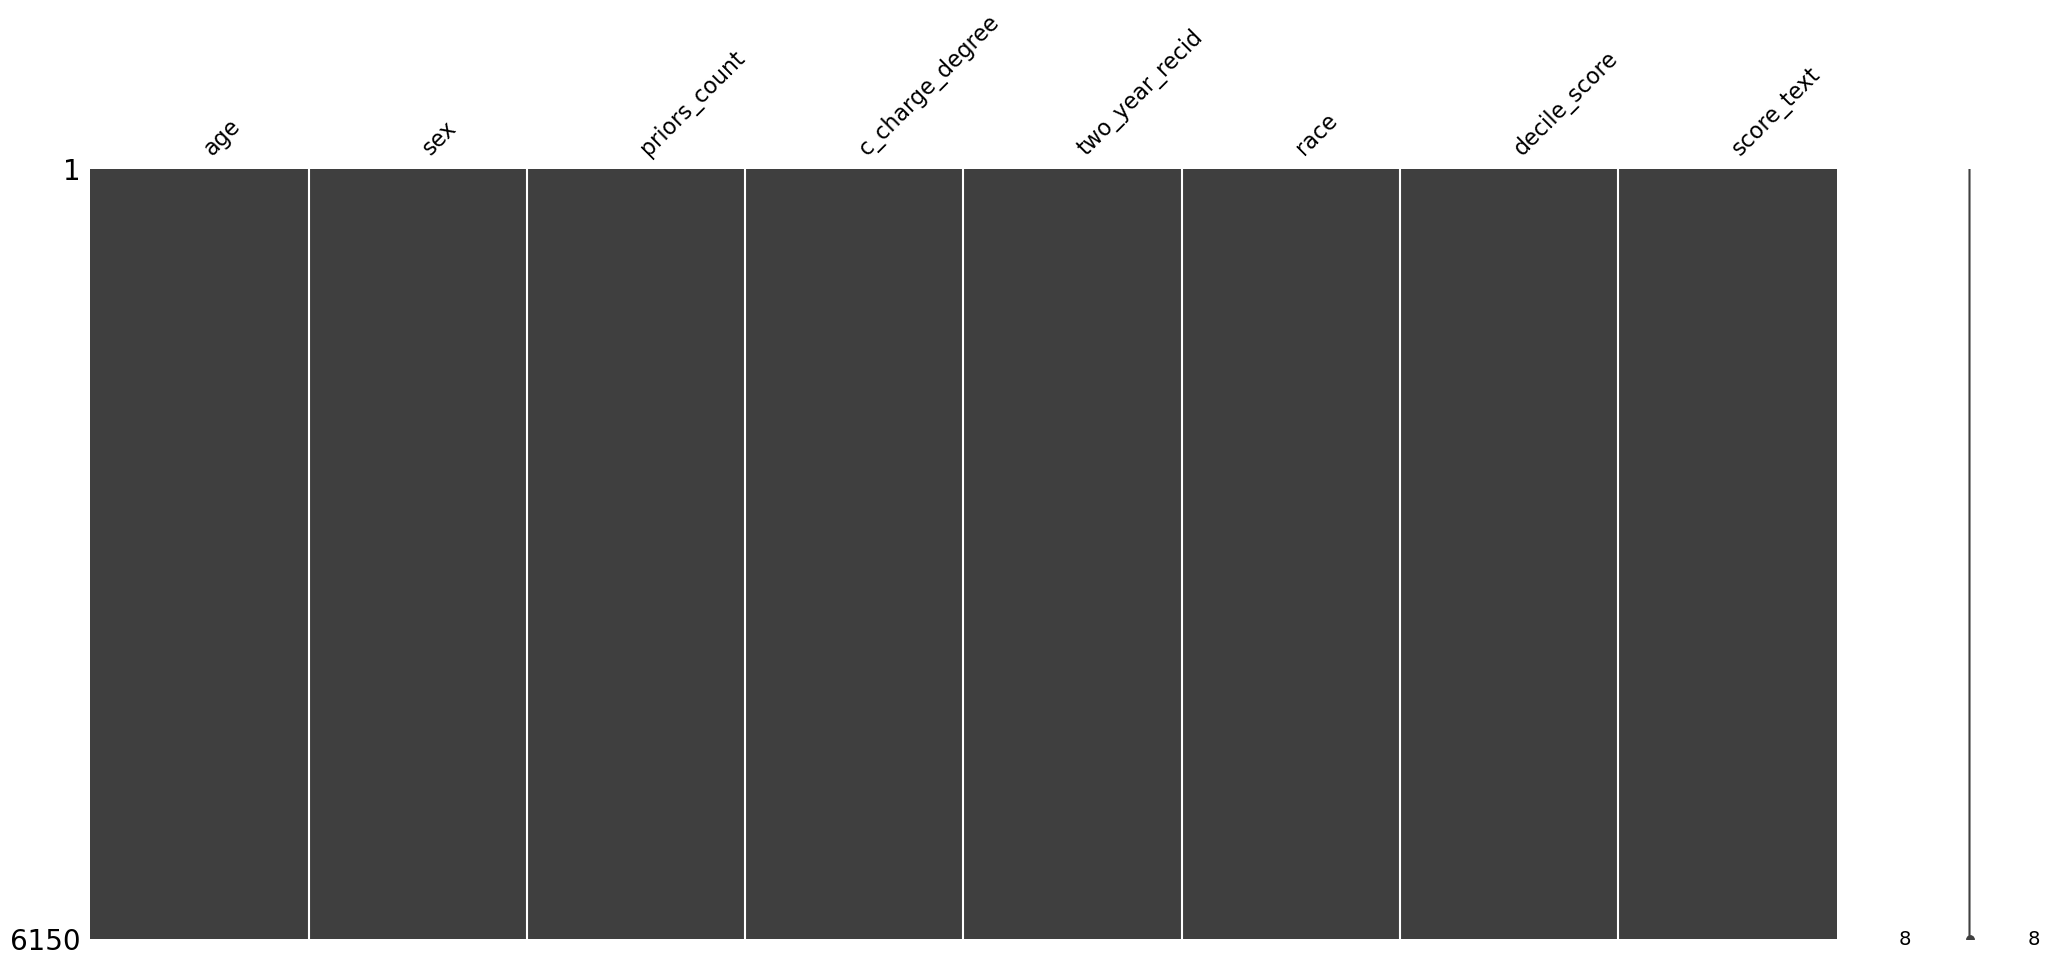

In [6]:
msno.matrix(compas_subset)

**Interpretation of missingness diagnostics**

The missingness matrix shows that the selected variables are complete for the filtered dataset: there are no missing values in the features, outcome, or group identifiers used in the analysis.

As a result:

- No observations need to be removed at this stage

- No imputation is required

- The full filtered dataset can be retained for modelling

:::callout-note
Although missing data are common in administrative criminal justice datasets, the variables selected for this analysis are complete for the filtered sample. This highlights an important point: missing data handling should be driven by empirical diagnostics rather than applied automatically. In this case, neither deletion nor imputation is required.
:::

### Final analysis dataset

Since no missing values are present in the selected variables, we proceed using the full subset as our analysis dataset.

In [7]:
# Final analysis dataset (no rows dropped and no imputation)
compas_clean = compas_subset.copy()

print(f"Final dataset size: {compas_clean.shape[0]} observations")
print(f"Recidivism rate: {compas_clean[target_col].mean():.2%}")

Final dataset size: 6150 observations
Recidivism rate: 46.62%


### Summary

At this point, the data has been:

- filtered to the relevant population,

- restricted to the variables of interest,

- and checked for missingness.

No further preprocessing is required at this stage, and we can proceed to feature engineering and model fitting using the complete dataset.

## 1.7 Feature Engineering

Before fitting any model, we need to transform the raw variables into a form that can be used by statistical and machine-learning algorithms. This step—**feature engineering**—is where modelling assumptions become explicit.

At this stage, feature engineering serves three related purposes:

1. Converting categorical variables into numerical form so they can be used by the model
2. Making explicit which variables are allowed to influence predictions
3. Preparing additional variables that will be needed later for evaluation and comparison

::: callout-tip
Feature engineering is not a neutral technical step.
It reflects deliberate choices about what information is considered relevant and permissible for prediction.
:::

### Encoding categorical variables

Several variables in the dataset are categorical (e.g. sex, charge degree, race). Because most classification models operate on numerical inputs, categorical variables must be encoded before modelling.

For variables with two categories, we use **binary encoding**:

* `sex` → Male vs. not Male
* `c_charge_degree` → Felony vs. misdemeanor

Each encoded variable takes the value:

* `1` if the condition is true
* `0` otherwise

In [8]:
# Encode categorical variables
compas_clean['sex_encoded'] = (compas_clean['sex'] == 'Male').astype(int)
compas_clean['charge_felony'] = (compas_clean['c_charge_degree'] == 'F').astype(int)

Binary encoding has two advantages here:

* It preserves all available information for two-category variables
* It makes coefficient interpretation straightforward later on

::: callout-tip

### Encoding vs. dummy variables: when to use which (and why)

* **Two categories** → use a **single binary (0/1) indicator**
  *Why?*
  A single indicator captures all available information without redundancy.
  Creating two indicators would introduce perfect collinearity, so one would have to be dropped anyway.

  *Example:*
  `sex_encoded = 1` (Male), `0` (Female)

* **More than two categories** → use **dummy (one-hot) variables**, with a reference category dropped
  *Why?*
  Multi-category variables cannot be represented by a single column without imposing an artificial ordering.
  Dummy variables allow the model to estimate a separate effect for each category relative to a baseline.

  *Example:*
  Suppose **charge type** has three categories: *Felony*, *Misdemeanor*, *Infraction*.
  We choose *Infraction* as the reference category and create two indicators:

  | Charge type | Felony | Misdemeanor |
  | ----------- | ------ | ----------- |
  | Felony      | 1      | 0           |
  | Misdemeanor | 0      | 1           |
  | Infraction  | 0      | 0           |

  In this encoding, the model estimates:

  * the difference between **Felony and Infraction**, and
  * the difference between **Misdemeanor and Infraction**.

* **Continuous variables** → no encoding needed
  *Why?*
  Continuous variables already carry meaningful numerical information.

⚠️ **Warning:**
Do **not** encode nominal categories as numbers (e.g. `Low=1`, `Medium=2`, `High=3`) unless the variable is truly ordinal.
Doing so implicitly tells the model that the categories are ordered and evenly spaced.

**Key rule:**
The number of columns required is *(number of categories − 1)* — enough to represent all differences without redundancy.

:::


### Why race is encoded but not used as a predictor

We also create a binary encoding of race:

In [9]:
compas_clean['race_encoded'] = (compas_clean['race'] == 'African-American').astype(int)

This naturally raises the question of why race is encoded if it is not used as a predictor.

::: callout-important
Race is encoded for **evaluation**, not for **prediction**.
:::

Encoding race allows us to:

* retain a consistent numerical representation across the dataset
* compute group-based summaries and diagnostics later
* examine how model behaviour differs across groups

Crucially, encoding race does **not** mean that race influences the model. Influence occurs only when a variable is included in the predictor matrix `X`.

::: callout-warning
Encoding a variable does not imply it is used for prediction.
Only variables included in `X` are seen by the model.
:::

This distinction—between *what is stored* and *what is predicted from*—is central to responsible modelling.

### Defining predictors and outcome

We now explicitly separate:

* **Predictors (features)**: variables used to generate predictions
* **Outcome (target)**: the variable we aim to predict

In [10]:
# Feature matrix X and target y
# NOTE: Race is deliberately excluded from X
X = compas_clean[['age', 'sex_encoded', 'priors_count', 'charge_felony']].copy()
y = compas_clean[target_col].copy()

print("Feature matrix shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Feature matrix shape: (6150, 4)

Target distribution:
two_year_recid
0    0.533821
1    0.466179
Name: proportion, dtype: float64


Race is deliberately excluded from `X` to ensure that predictions do not directly depend on group membership. At this stage, we simply verify that the feature matrix and outcome variable are correctly constructed.

## 1.8 Train–Test Split

To evaluate how well a model generalises beyond the data on which it is trained, we split the dataset into **training** and **test** sets.

* The **training set** is used to estimate model parameters
* The **test set** is held out and used only to assess performance

This separation ensures that model evaluation reflects behaviour on unseen data rather than memorisation of the training sample.

### Why a 70/30 split?

We allocate **70% of the data to training** and **30% to testing**, which is a common and well-established default.

This choice reflects a trade-off:

* The training set must be large enough to allow the model to learn meaningful patterns
* The test set must be large enough to provide a stable and informative evaluation

With moderate-sized datasets like COMPAS, a 70/30 split typically provides:

* sufficient data for model estimation
* enough held-out observations to reliably summarise performance

Other splits are possible, but the key principle is balancing learning capacity with evaluation reliability.

### Stratified splitting

Because the outcome exhibits class imbalance, we use a stratified split. This ensures that the relative proportion of recidivism and non-recidivism cases is similar in both the training and test sets.

Rather than splitting predictors and outcomes separately, we first split the full dataset and then derive all required subsets from this single split. This guarantees that all downstream analyses are based on exactly the same train–test partition.

In [11]:
# Single stratified split on the full dataset
compas_train, compas_test = train_test_split(
    compas_clean,
    test_size=0.3,
    random_state=42,
    stratify=compas_clean[target_col]
)

:::
Stratification preserves the structure of the outcome variable across splits.
Without it, one subset could contain disproportionately many recidivism cases.
:::

::: callout-warning

### Stratified splitting: classification vs. regression

**Stratification depends on the type of outcome variable.**

In **classification problems**, the outcome variable takes a small number of discrete values (e.g. recidivism vs. no recidivism).
In this setting, **stratified splitting of the outcome** ensures that each class is represented in similar proportions in both the training and test sets.

This is why stratification is appropriate in this analysis.

In **regression problems**, the outcome variable is continuous. There are no discrete outcome classes to preserve, so **stratifying on the outcome is generally not meaningful** and can be misleading.

Stratifying a continuous outcome typically requires arbitrary binning, which:

* introduces artificial thresholds,
* distorts the outcome distribution,
* and can bias model evaluation.

For regression tasks, standard random splitting is usually sufficient.

Importantly, this does **not** mean that stratification is never appropriate in regression contexts:

* stratifying **by a categorical predictor** (e.g. region, gender) can be useful for ensuring representation,
* but stratifying **by the regression outcome itself** should generally be avoided.

**Rule of thumb:**
Stratify the **outcome** for classification problems, not for regression.

:::


### Constructing training and test sets for modelling

Once the full dataset has been split, we construct the predictor matrix and outcome variable from the same split, ensuring perfect alignment.

In [12]:
# Define predictors and outcome from the split data
X_train = compas_train[['age', 'sex_encoded', 'priors_count', 'charge_felony']]
y_train = compas_train[target_col]

X_test = compas_test[['age', 'sex_encoded', 'priors_count', 'charge_felony']]
y_test = compas_test[target_col]

print(f"Training set: {X_train.shape[0]} observations ({y_train.mean():.2%} recidivism)")
print(f"Test set: {X_test.shape[0]} observations ({y_test.mean():.2%} recidivism)")

Training set: 4305 observations (46.62% recidivism)
Test set: 1845 observations (46.61% recidivism)


This approach ensures that:

- each observation appears in exactly one of the training or test sets,

- all variables (predictors, outcomes, and group labels) remain aligned,

- later analyses—particularly group-based evaluation—are internally consistent.

### Why this design choice matters

By defining the train–test split once and deriving all modelling objects from it, we treat the split as part of the experimental design rather than a purely technical step.

This reduces the risk of subtle inconsistencies and makes the logic of the analysis easier to follow and audit.

> From this point on, all models are trained only on `compas_train` and evaluated only on `compas_test`.

:::callout-warning

One split per analysis pipeline

An analytical pipeline should use a single train–test split throughout.

Using different splits for different models or evaluation steps means that models are no longer being compared on the same data, which can:

- artificially inflate or deflate performance,

- make model comparisons unreliable,

- and obscure whether differences are due to the model or the data split.

For fair and meaningful comparison, all models, metrics, and group-based analyses must be evaluated on the same held-out test set.

:::

## 1.9 Feature Scaling

The features used for prediction are measured on different scales:

* age (years)
* number of prior charges
* binary indicators

Many machine-learning algorithms are sensitive to such differences in scale. If left unaddressed, features with larger numeric ranges can disproportionately influence the model.

### Standardisation

To avoid this, we apply **standardisation**, which rescales each feature so that it has:

* mean 0
* standard deviation 1

In [13]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

::: callout-warning
The scaler is fit **only on the training data** and then applied to the test data.
Fitting on the full dataset would leak information from the test set into training.
:::

### Verifying the transformation

In [14]:
print("Scaled feature means (should be ~0):")
print(X_train_scaled.mean().round(3))

Scaled feature means (should be ~0):
age              0.0
sex_encoded      0.0
priors_count    -0.0
charge_felony    0.0
dtype: float64


This final check confirms that the scaling step has been applied correctly.

## Where we are now

At this point, the data have been:

* encoded into numerical form
* split into training and test sets
* scaled appropriately for modelling

We are now ready to fit classification models and begin formal evaluation.

---

# Part 2: Classification Recap (Complete) 📚

Last week we introduced logistic regression up to the sigmoid function. Let's complete that foundation with fitting, interpretation, and comprehensive evaluation metrics.

## 2.1 Fitting Logistic Regression

### 2.1.1 How Logistic Regression Works (Quick Recap)

Logistic regression starts exactly like linear regression—it forms a **linear combination** of predictors:

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p
$$

But instead of using $z$ directly as the prediction, logistic regression applies the **sigmoid function**:

$$
P(y=1|x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

This transformation has crucial effects:

1. **Constrains output to [0,1]** → interpretable as probability
2. **Creates S-shaped curve** → probabilities saturate near 0 and 1
3. **Allows natural decision rule** → classify as 1 if $P(y=1|x) \geq 0.5$

::: callout-tip

### From the sigmoid to log-odds (with derivation)

Logistic regression **defines** the probability of the positive class using the sigmoid function:

$$
P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}},
\quad \text{where } z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p
$$

To understand what the model is *linear* in, we algebraically invert the sigmoid.

**Step 1: Start from the sigmoid**
$$
P = \frac{1}{1 + e^{-z}}
$$

**Step 2: Rearrange**
$$
1 + e^{-z} = \frac{1}{P}
$$

$$
e^{-z} = \frac{1 - P}{P}
$$

**Step 3: Take reciprocals**
$$
e^{z} = \frac{P}{1 - P}
$$

**Step 4: Take logarithms**
$$
z = \log\left(\frac{P}{1 - P}\right)
$$

The quantity
$$
\log\left(\frac{P(y=1 \mid x)}{1 - P(y=1 \mid x)}\right)
$$
is called the **log-odds** (or **logit**).

**Key takeaway:**

Logistic regression is **not linear in probabilities**, but it *is* linear in the **log-odds** of the outcome.

This is why logistic regression belongs to the class of **generalized linear models (GLMs)**:

* the predictors enter linearly through $z$,
* a **link function** (the logit) connects that linear predictor to the mean of the outcome.

:::

### 2.1.2 Maximum Likelihood Estimation (MLE)

Unlike linear regression (which minimizes squared errors), logistic regression finds coefficients using **Maximum Likelihood Estimation**.

**The idea:**

* We have observed data: defendants with known recidivism outcomes
* Our model produces a probability for each defendant
* MLE asks: *which coefficients make the observed outcomes most probable?*

**Formally:**

For each observation $i$, the model predicts $P(y_i = 1|x_i)$. The likelihood of observing the actual outcome is:

$$
L(\beta) = \prod_{i=1}^{n} P(y_i|x_i)^{y_i} \times (1 - P(y_i|x_i))^{1-y_i}
$$

We find coefficients $\beta$ that **maximize** this likelihood (or equivalently, minimize the negative log-likelihood).

**Why this matters:**

* No closed-form solution like OLS—requires iterative optimization
* Convergence warnings mean the optimizer struggled to find a maximum
* Can fail under perfect separation (likelihood has no finite maximum)

### 2.1.3 Fitting Our Model

In [15]:
# Fit logistic regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Get predictions
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Get predicted probabilities (the actual output of the sigmoid function)
y_train_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Model fitted successfully!")
print(f"\nConvergence after {log_reg.n_iter_[0]} iterations")

Model fitted successfully!

Convergence after 4 iterations


## 2.2 Interpreting Coefficients

### 2.2.1 What Logistic Regression Actually Models

Logistic regression does **not** model the outcome directly. Instead, it models the **log-odds** of the positive class:

$$
\log\left(\frac{P(y=1)}{1 - P(y=1)}\right)
= \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p
$$

Rather than predicting probabilities directly, the model assumes that the **log-odds of the outcome** can be expressed as a linear function of the predictors.

**Why log-odds?** This keeps the right-hand side linear in predictors while ensuring probabilities stay in $[0,1]$.

*We will see shortly how this log-odds formulation is converted back into probabilities for prediction.*

### 2.2.2 From Probabilities to Odds to Log-Odds (and back)

Let's build intuition step by step.

**Step 1: Probabilities**

* $P(\text{recidivism}) = 0.5$ means a 50% chance of reoffending
* This is what we ultimately care about, but it is not what the model works with directly

**Step 2: Odds**

$$
\text{Odds}
= \frac{P(y=1)}{1 - P(y=1)}
= \frac{P(\text{yes})}{P(\text{no})}
$$

Interpretation:

* If $P = 0.5$, odds = $1$ (equally likely)
* If $P = 0.75$, odds = $3$ (three times more likely to reoffend than not)
* If $P = 0.25$, odds = $1/3$ (three times more likely *not* to reoffend)

**Odds express relative likelihood** — they range from $0$ to $+\infty$.

**Step 3: Log-Odds (Logit)**

Taking the logarithm:

$$
\log(\text{Odds}) = \log\left(\frac{P}{1-P}\right)
$$

* Log-odds range from $-\infty$ to $+\infty$ (like the linear predictor)
* This is the quantity that is assumed to be linear in the predictors


::: callout-tip

### From log-odds back to probabilities 

Logistic regression models the **log-odds** of the outcome as a linear function of the predictors:

$$
\log\left(\frac{P(y=1)}{1 - P(y=1)}\right) = z
\quad \text{where} \quad
z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p
$$

To obtain probabilities, we simply **invert this transformation**.

**Step 1: Undo the logarithm**

Exponentiating both sides:

$$
\frac{P(y=1)}{1 - P(y=1)} = e^{z}
$$

This quantity represents the **odds** of the positive outcome.

**Step 2: Solve for the probability**

Rearranging gives:

$$
P(y=1) = \frac{e^{z}}{1 + e^{z}}
= \frac{1}{1 + e^{-z}}
$$

This function is the **sigmoid (logistic) function**, which maps any real-valued input to a valid probability in ([0,1]).

#### A numerical example

Consider three values of the linear predictor (z):

**Case 1: $z = 0$**

$$
P(y=1) = 0.5
$$

* Log-odds = 0
* Odds = 1
* Outcome equally likely

This corresponds to the default decision boundary used by `.predict()`.


**Case 2: $z = 2$**

$$
P(y=1) \approx 0.88
$$

* Positive log-odds
* Odds strongly favour recidivism
* High predicted probability

**Case 3: $z = -2$**

$$
P(y=1) \approx 0.12
$$

* Negative log-odds
* Odds strongly favour no recidivism
* Low predicted probability


#### Visualising the sigmoid transformation

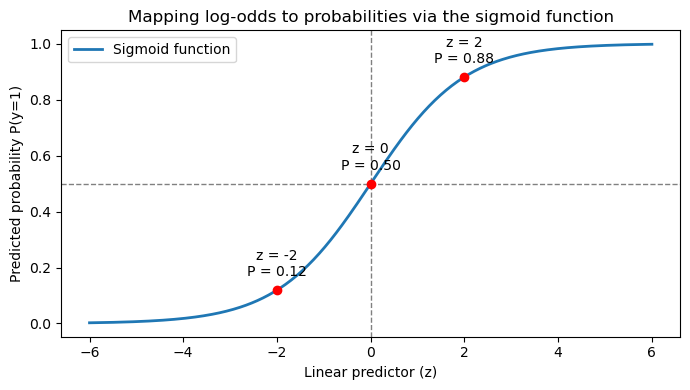

In [16]:
z = np.linspace(-6, 6, 400)
sigmoid = 1 / (1 + np.exp(-z))

z_points = np.array([-2, 0, 2])
p_points = 1 / (1 + np.exp(-z_points))

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid, label="Sigmoid function", linewidth=2)
plt.scatter(z_points, p_points, color="red", zorder=3)

for zp, pp in zip(z_points, p_points):
    plt.annotate(
        f"z = {zp}\nP = {pp:.2f}",
        (zp, pp),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

plt.axhline(0.5, color="grey", linestyle="--", linewidth=1)
plt.axvline(0, color="grey", linestyle="--", linewidth=1)

plt.xlabel("Linear predictor (z)")
plt.ylabel("Predicted probability P(y=1)")
plt.title("Mapping log-odds to probabilities via the sigmoid function")
plt.legend()
plt.tight_layout()
plt.show()

**Key takeaway**

* Logistic regression is **linear in log-odds**, not in probabilities
* The sigmoid function converts log-odds back into valid probabilities
* `.predict_proba()` applies exactly this transformation internally

This is why logistic regression is a **generalized linear model**.

:::

### 2.2.3 Interpreting the Coefficients

::: callout-important

### Interpreting coefficients after feature scaling

All predictors were **standardised** before fitting the model.

As a result:

* Each coefficient represents the change in **log-odds** associated with a
  **one–standard-deviation increase** in the predictor.

If predictors were not scaled, coefficients would instead correspond to a
**one-unit increase in the predictor’s original measurement units**.

Scaling does **not** change predictions or model performance — it only changes
the **unit of interpretation** and makes coefficients directly comparable.
:::

In [17]:
# Display coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

print("Logistic Regression Coefficients:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {log_reg.intercept_[0]:.3f}")

Logistic Regression Coefficients:
      Feature  Coefficient  Odds Ratio
 priors_count     0.732574    2.080428
          age    -0.549068    0.577488
  sex_encoded     0.131536    1.140579
charge_felony     0.101409    1.106730

Intercept: -0.140


**How to read this table:**

**Coefficient ($\beta_j$):**

* Change in **log-odds** for a one–standard-deviation increase in feature $j$
* Positive coefficient → increases log-odds (recidivism more likely)
* Negative coefficient → decreases log-odds (recidivism less likely)

**Odds Ratio ($e^{\beta_j}$):**

* Expresses the same effect on the odds scale
* OR > 1 → odds increase
* OR < 1 → odds decrease
* OR = 1 → no association

### Example interpretation (using fitted coefficients)

From the fitted logistic regression model, the estimated coefficient for `priors_count` is:

$$
\beta_{\text{priors}} = 0.733
\quad \Rightarrow \quad
\text{OR} = e^{0.733} \approx 2.08
$$

**Holding all other predictors constant**, this can be interpreted step by step.

**Log-odds interpretation**

* A **one–standard-deviation increase** in prior convictions increases the **log-odds** of recidivism by **0.73**, **holding age, sex, and charge type fixed**.

**Odds interpretation**

* Exponentiating the coefficient gives an **odds ratio of about 2.08**.
* This means that, **for two otherwise comparable individuals**, the one who is one standard deviation higher in prior convictions has **just over double the odds** of recidivism.

**Plain-English summary (odds scale)**

* Among individuals who are similar in age, sex, and charge severity, a higher prior conviction history is strongly associated with increased likelihood of reoffending.


#### From log-odds to probabilities (illustrative)

To see what this implies for **predicted probabilities**, we must specify a **baseline**.

Because predictors are standardised, a natural reference point is an individual with **average values on all predictors** (all scaled predictors equal to zero).

For such an individual, the linear predictor equals the intercept:

$$
z_{\text{baseline}} = \beta_0 = -0.140
$$

Applying the sigmoid function:

$$
P_{\text{baseline}}
= \frac{1}{1 + e^{-(-0.140)}}
\approx 0.47
$$

So, for an “average” individual, the model predicts a recidivism probability of about **47%**.

Now consider increasing `priors_count` by **one standard deviation**, **holding all other predictors constant**:

$$
z_{\text{new}} = -0.140 + 0.733 = 0.593
$$

Converting this log-odds value back to a probability:

$$
P_{\text{new}}
= \frac{1}{1 + e^{-0.593}}
\approx 0.64
$$

#### Interpreting the probability change

* Log-odds increase by **0.73**
* Odds increase by a factor of **2.08**
* Predicted probability increases from **47% to 64%**, **for individuals who differ only in prior convictions**

#### Important clarification

This probability change:

* is **conditional** on the values of the other predictors,
* depends on the **baseline risk level**,
* and is **not a universal effect** of `priors_count`.

This is why logistic regression coefficients are interpreted on the **log-odds or odds scale**, while probability changes are examined using **predicted values for specific cases**.

### 2.2.4 Important: Odds vs. Probabilities

⚠️ **Critical distinction:** Logistic regression coefficients describe changes in **odds**, not **probabilities**.

A given change in odds does **not** correspond to a fixed change in probability.

**Why?** Because the effect on probability depends on the baseline risk:

* If baseline $P = 0.01$, doubling the odds leads to a very small probability change
* If baseline $P = 0.50$, doubling the odds leads to a large probability change

This is why we focus on odds ratios rather than percentage-point changes in probability.

## 2.3 Basic Classification Metrics

So far, we have focused on model estimation and interpretation:

- logistic regression produces log-odds,

- which are converted into probabilities via the sigmoid function.

However, in many applied settings, decisions are ultimately **binary**.

At some point, predicted probabilities must be converted into class labels (e.g. “recidivism” vs. “no recidivism”), typically by applying a classification threshold.

Once predictions are expressed as class labels, model performance can no longer be summarised by a single number.
Instead, we must account for different types of classification errors, which may carry very different real-world consequences.

This motivates the use of the confusion matrix, the basic building block of classification evaluation.

:::callout-note

A note on classification thresholds

By default, `.predict()` (function that converts log odds to probabilities to class labels, in the case of logistic regression) uses a threshold of 0.5, meaning observations with a predicted probability of at least 50% are classified as the positive class (here, recidivism).

This default is convenient and intuitive (it corresponds to equal odds of both outcomes), but it is not inherently optimal and may not be appropriate when the costs of false positives and false negatives differ.
:::

### 2.3.1 Confusion Matrix

A **confusion matrix** is the foundation of classification evaluation. It cross-tabulates predicted vs. actual classes.

**Why do we need it?**

Classification has **multiple types of errors**:

* Predicting recidivism when someone won't reoffend (false alarm or false positive)
* Predicting no recidivism when someone will reoffend (missed case or false negative)

These errors have **different consequences** in practice.

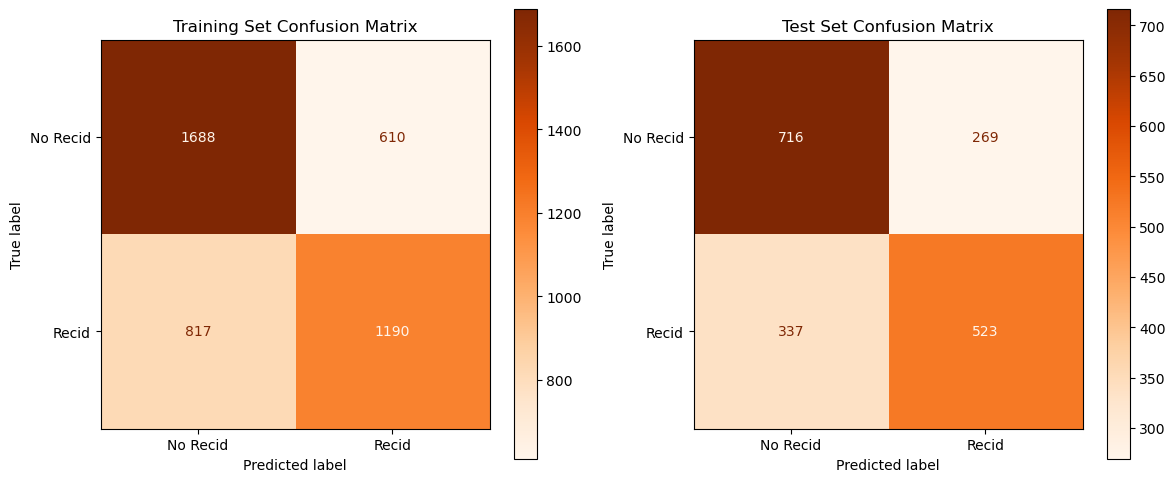

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred,
    display_labels=['No Recid', 'Recid'],
    cmap='Oranges',
    ax=axes[0]
)
axes[0].set_title('Training Set Confusion Matrix')

# Test set
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['No Recid', 'Recid'],
    cmap='Oranges',
    ax=axes[1]
)
axes[1].set_title('Test Set Confusion Matrix')

plt.tight_layout()
plt.show()

**Reading the matrix:**

|                     | **Predicted: No Recid** | **Predicted: Recid** |
|---------------------|-------------------------|----------------------|
| **Actual: No Recid**| True Negative (TN)      | False Positive (FP)  |
| **Actual: Recid**   | False Negative (FN)     | True Positive (TP)   |

**In context of criminal justice:**

* **True Negative (TN):** Correctly predicted low risk → resource saved appropriately
* **False Positive (FP):** Incorrectly flagged as high risk → person faces unwarranted restrictions
* **False Negative (FN):** Missed a future reoffender → potential harm to public safety
* **True Positive (TP):** Correctly identified high risk → appropriate intervention

**Why FP and FN are not symmetric:**

The costs differ dramatically:

* **FP (Type I error):** Person unnecessarily detained, denied bail, faces harsher conditions
* **FN (Type II error):** Person released who goes on to harm others

Which is worse? This is **not a technical question**—it's an ethical and policy choice.

Different applications prioritize differently:

* Medical diagnosis: FN often worse (missing disease)
* Spam filtering: FP often worse (losing important email)
* Criminal justice: **Depends on values** about liberty vs. safety

#### Interpreting the matrix

Both confusion matrices show a **similar error structure** on the training and test sets, suggesting that the model generalises reasonably well and is not obviously overfitting.

Across both splits:

* The model correctly identifies a substantial number of **non-recidivism cases** (true negatives).
* It also correctly identifies many **recidivism cases** (true positives), but at the cost of a non-trivial number of errors in both directions.

Two patterns stand out:

1. **False positives are common**
   A sizeable number of individuals who do *not* reoffend are classified as high risk.
   In a criminal justice context, this corresponds to people being flagged as risky when they would not have reoffended.

2. **False negatives are also present**
   Some individuals who do reoffend are classified as low risk, representing missed cases.

Importantly, **false positives and false negatives are not symmetric in their consequences**.
The matrices make clear that improving performance in one direction will typically worsen it in the other, highlighting the need to think carefully about **what kinds of errors matter most**.

At this stage, we simply observe these patterns.
In the next sections, we will formalise them using **classification metrics** that quantify different aspects of performance and make these trade-offs explicit.


### 2.3.2 Classification Metrics: Different Questions, Different Answers

All classification metrics are functions of the confusion matrix, but they answer **different questions** and prioritize **different aspects** of performance.

In [19]:
# Calculate metrics for both sets
metrics_train = {
    'Accuracy': accuracy_score(y_train, y_train_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_train, y_train_pred),
    'Precision': precision_score(y_train, y_train_pred),
    'Recall': recall_score(y_train, y_train_pred),
    'F1 Score': f1_score(y_train, y_train_pred)
}

metrics_test = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1 Score': f1_score(y_test, y_test_pred)
}

# Display as table
metrics_df = pd.DataFrame({
    'Training': metrics_train,
    'Test': metrics_test,
    'Difference': {k: metrics_train[k] - metrics_test[k] for k in metrics_train}
})

print("Classification Metrics:")
print(metrics_df.round(3))

Classification Metrics:
                   Training   Test  Difference
Accuracy              0.669  0.672      -0.003
Balanced Accuracy     0.664  0.668      -0.004
Precision             0.661  0.660       0.001
Recall                0.593  0.608      -0.015
F1 Score              0.625  0.633      -0.008


**Let's understand each metric:**

#### Accuracy: The Obvious (but Flawed) Choice

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{\text{Correct}}{\text{Total}}
$$

**What it measures:** Proportion of all predictions that are correct.

**Why it's often misleading:**

Imagine a dataset where only 5% of defendants reoffend. A model that **always predicts "no recidivism"** achieves:

* Accuracy = 95% ✓ (looks great!)
* But catches exactly 0% of actual reoffenders ✗

Accuracy is dominated by the majority class—it can hide complete failure on the class you care about.

⚠️ **Rule:** Never use accuracy when classes are imbalanced (which they often are in real problems!).

#### Precision: When You Flag Someone, Are You Right?

$$
\text{Precision} = \frac{TP}{TP + FP} = \frac{TP}{\text{All Predicted Positive}}
$$

**The question it answers:** "Of all the people we flagged as high risk, what fraction actually reoffended?"

**When to prioritize precision:**

* When false alarms are costly
* When you want to trust positive predictions
* Example: Spam filtering (false positives = lost important emails)

**In criminal justice:** High precision means few people are wrongly detained.

#### Recall (Sensitivity): Of All Who Reoffend, How Many Do We Catch?

$$
\text{Recall} = \frac{TP}{TP + FN} = \frac{TP}{\text{All Actual Positive}}
$$

**The question it answers:** "Of all the people who actually reoffended, what fraction did we identify?"

**When to prioritize recall:**

* When missing cases is costly
* When you need comprehensive detection
* Example: Medical screening (false negatives = missed disease)

**In criminal justice:** High recall means we catch most future reoffenders.

#### The Precision-Recall Trade-off

These two metrics are in **tension**:

* To increase precision → be more selective (higher threshold)
  * But then you miss more cases (lower recall)

* To increase recall → flag more people (lower threshold)
  * But then you get more false alarms (lower precision)

**Example with our model:**

* If we set threshold = 0.3 (more lenient):
  * Higher recall (catch more reoffenders)
  * Lower precision (more false alarms)

* If we set threshold = 0.7 (more strict):
  * Higher precision (fewer false alarms)
  * Lower recall (miss more reoffenders)

#### F1 Score: Balancing Precision and Recall

$$
\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**What it measures:** Harmonic mean of precision and recall.

**Why harmonic mean?** It severely penalizes low values—F1 is only high when **both** precision and recall are high.

**When to use F1:**

* When you need a single-number summary
* When you care about both precision and recall equally
* When classes are imbalanced (more informative than accuracy)

**Interpretation in our results:**

Looking at our test set metrics, what do they tell us about our model's behavior?

#### Balanced Accuracy: Treating Both Classes Fairly

$$
\text{Balanced Accuracy} = \frac{1}{2}\left(\frac{TP}{TP+FN} + \frac{TN}{TN+FP}\right)
$$

**What it measures:** Average of recall for each class (also called "macro-averaged recall").

**Why it's better than accuracy:** Gives equal weight to both classes, regardless of their frequency.

In our "always predict no recidivism" example:

* Balanced accuracy = 50% (correctly identifies the failure)

:::callout-note

### Interpreting the classification metrics (train vs. test) in the COMPAS example

Across all reported metrics, training and test performance are very similar, with differences on the order of one to two percentage points.
This suggests that the model generalises reasonably well and shows no strong evidence of overfitting.

Looking at the metrics themselves:

- Accuracy (~67%) and balanced accuracy (~67%) are close, indicating that performance is not being driven solely by the majority class.

- Precision (~66%) means that about two-thirds of individuals flagged as high risk do, in fact, reoffend.

- Recall (~60%) indicates that the model identifies a majority—but not all—future reoffenders, missing a non-trivial fraction.

- F1 score (~63%) reflects a moderate balance between precision and recall, rather than extreme performance in either direction.

Taken together, these results describe a model that is moderately accurate, reasonably stable across samples, and clearly subject to trade-offs between false positives and false negatives.

At this stage, these metrics are all computed at a single classification threshold (0.5).
In the next section, we move beyond this single operating point and evaluate how model performance changes across all possible thresholds using the ROC curve.

:::

## 2.4 ROC Curve and AUC: Evaluating Across All Thresholds

### 2.4.1 The Threshold Problem

So far, we've used a single threshold (0.5) to convert probabilities to class predictions. But this is **arbitrary**.

**Why does this matter?**

Consider two defendants:

* Defendant A: $P(\text{recid}) = 0.49$ → Predicted: No
* Defendant B: $P(\text{recid}) = 0.51$ → Predicted: Yes

They're nearly identical in risk, but get opposite classifications!

**Different thresholds give different confusion matrices:**

* Lower threshold (e.g., 0.3): More people flagged → higher recall, lower precision
* Higher threshold (e.g., 0.7): Fewer people flagged → lower recall, higher precision

**The question:** How do we evaluate performance across **all possible thresholds**?

### 2.4.2 The ROC Curve

The **ROC (Receiver Operating Characteristic) curve** solves this by plotting model performance at every threshold.

**What it plots:**

* **X-axis:** False Positive Rate (FPR) = $\frac{FP}{FP + TN}$
  * Proportion of negatives incorrectly classified as positive
  * "False alarm rate"

* **Y-axis:** True Positive Rate (TPR) = $\frac{TP}{TP + FN}$
  * Same as Recall
  * "Hit rate" or "sensitivity"

**How it works:**

1. Start with highest possible threshold (≈1.0): Predict almost everyone as negative
   * TPR ≈ 0 (miss everyone)
   * FPR ≈ 0 (no false alarms)
   * Point at (0, 0)

2. Gradually lower threshold: More people predicted positive
   * Both TPR and FPR increase

3. End with lowest threshold (≈0.0): Predict almost everyone as positive
   * TPR ≈ 1 (catch everyone)
   * FPR ≈ 1 (many false alarms)
   * Point at (1, 1)

The ROC curve traces this path.

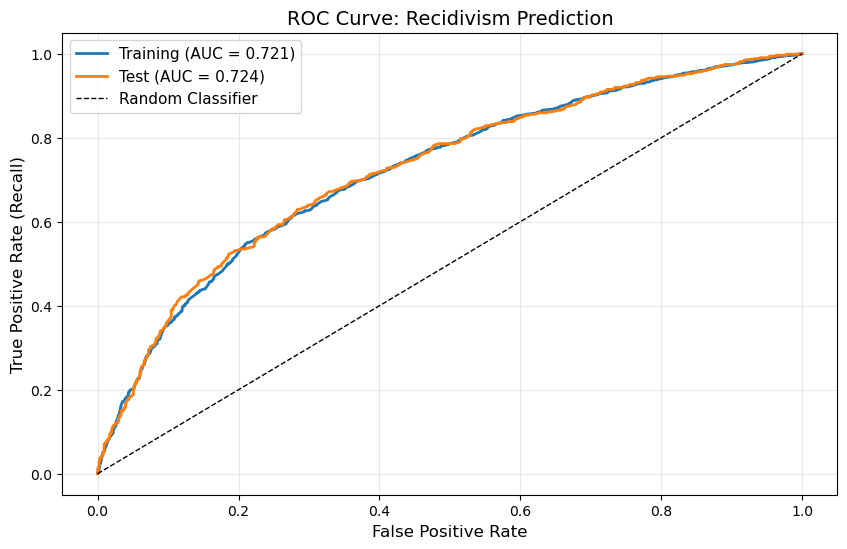

Training AUC: 0.721
Test AUC: 0.724


In [20]:
# Calculate ROC curve
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {auc_train:.3f})', linewidth=2)
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {auc_test:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve: Recidivism Prediction', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print(f"Training AUC: {auc_train:.3f}")
print(f"Test AUC: {auc_test:.3f}")

### 2.4.3 Understanding the ROC Curve

**The diagonal (dashed line):**

* Represents a **random classifier** (coin flip)
* At any threshold, TPR = FPR (no discriminative ability)
* Example: 30% FPR → 30% TPR (just guessing)

**A good classifier:**

* Curve bows toward top-left corner
* At low FPR, already has high TPR
* Example: 10% FPR → 60% TPR (much better than random!)

**A perfect classifier:**

* Curve goes straight up to (0,1) then across to (1,1)
* Can achieve 100% TPR with 0% FPR at some threshold

### 2.4.4 AUC: A Single Number Summary

**AUC (Area Under the Curve)** summarizes the entire ROC curve:

$$
\text{AUC} = \int_0^1 TPR(FPR) \, d(FPR)
$$

**Interpretation:**

* AUC = 0.5: Random classifier (no better than chance)
* AUC = 1.0: Perfect classifier
* AUC = 0.7-0.8: Generally acceptable
* AUC = 0.8-0.9: Good
* AUC > 0.9: Excellent (rare in social sciences!)

**Probabilistic interpretation:**

AUC is the probability that the model assigns a higher score to a randomly chosen positive example than to a randomly chosen negative example.

In our context: If we pick a random reoffender and random non-reoffender, AUC is the probability our model assigns higher risk to the reoffender.

**Why AUC is useful:**

1. **Threshold-independent**: Evaluates discriminative ability across all thresholds
2. **Scale-invariant**: Cares about ranking, not absolute probabilities
3. **Classification-threshold-invariant**: Useful when deployment threshold might differ from 0.5

**Limitations:**

* Ignores calibration (whether probabilities are accurate)
* Can be misleading with severe class imbalance
* Doesn't tell you which threshold to use in practice

## 2.5 Precision-Recall Curve: When Classes Are Imbalanced

### 2.5.1 Why ROC-AUC Isn't Always Enough

ROC curves have a blind spot: they can be **overly optimistic** when classes are imbalanced. This does not mean ROC-AUC is wrong or useless, but that it can hide poor performance on the positive class when positives are rare.

**The problem:**

With highly imbalanced data (e.g., 2% positive class), a model can achieve:

* High TPR (catching most positives)
* Low FPR (because there are so many negatives)
* Good-looking ROC-AUC

But in absolute terms, it might flag 1000 people to catch 20 actual cases (2% precision)!

**Why this happens:**

FPR = $\frac{FP}{FP + TN}$ has a large denominator (many true negatives), so false positives don't hurt FPR much.

### 2.5.2 The Precision-Recall Curve

The **PR curve** focuses specifically on performance on the **positive class** (which we usually care most about).

**What it plots:**

* **X-axis:** Recall = $\frac{TP}{TP + FN}$
  * Same as TPR
  * "Of actual positives, what fraction did we catch?"

* **Y-axis:** Precision = $\frac{TP}{TP + FP}$
  * "Of predicted positives, what fraction are correct?"

**Key difference from ROC:**

Precision uses FP in the denominator (not TN), so it's **directly affected** by how many false alarms we make.

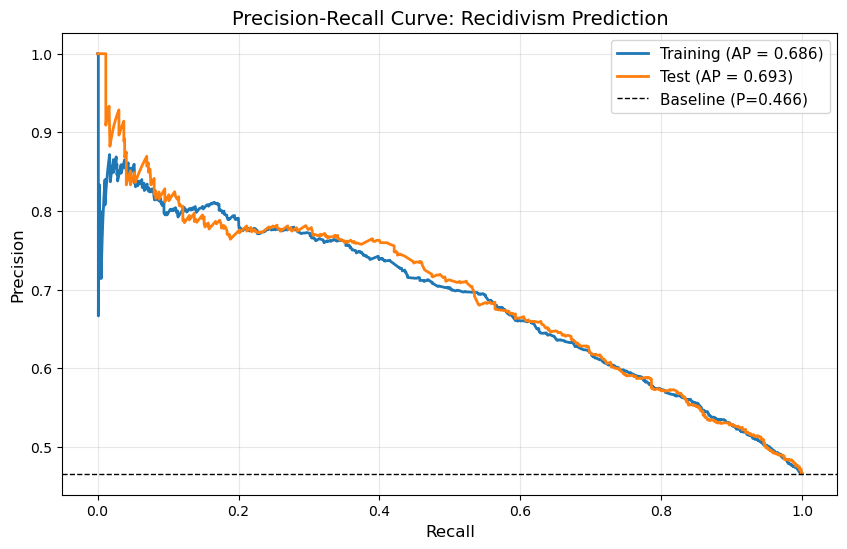

Training Average Precision: 0.686
Test Average Precision: 0.693
Baseline (random): 0.466


In [21]:
# Calculate PR curve
prec_train, rec_train, thresh_train = precision_recall_curve(y_train, y_train_proba)
prec_test, rec_test, thresh_test = precision_recall_curve(y_test, y_test_proba)

ap_train = average_precision_score(y_train, y_train_proba)
ap_test = average_precision_score(y_test, y_test_proba)

# Plot PR curve
plt.figure(figsize=(10, 6))
plt.plot(rec_train, prec_train, label=f'Training (AP = {ap_train:.3f})', linewidth=2)
plt.plot(rec_test, prec_test, label=f'Test (AP = {ap_test:.3f})', linewidth=2)

# Baseline (random classifier performance = proportion of positive class)
baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', 
            label=f'Baseline (P={baseline:.3f})', linewidth=1)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve: Recidivism Prediction', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print(f"Training Average Precision: {ap_train:.3f}")
print(f"Test Average Precision: {ap_test:.3f}")
print(f"Baseline (random): {baseline:.3f}")

### 2.5.3 Reading the PR Curve

**The baseline (dashed line):**

* Represents a random classifier
* Constant precision = proportion of positives in dataset
* In our case: ~46% of defendants reoffend, so random model has precision ≈ 0.46

**A good classifier:**

* Curve stays well above the baseline
* Maintains high precision even at high recall
* "Top-right corner" is ideal (perfect precision and recall)

**The inevitable trade-off:**

* **High recall, low precision:** We catch most reoffenders but flag many innocent people
  * Liberal threshold (more inclusive)
  
* **Low recall, high precision:** We're rarely wrong, but miss many reoffenders
  * Conservative threshold (more selective)

**Where this matters in practice:**

In criminal justice, this is a fundamental ethical tension:

* **Prioritize recall?** Catch more dangerous offenders but restrict more innocent people's freedom
* **Prioritize precision?** Fewer wrongful detentions but more crimes committed by those we release

### 2.5.4 Average Precision (AP)

**AP** summarizes the PR curve (like AUC for ROC):

$$
\text{AP} = \sum_n (R_n - R_{n-1}) P_n
$$

where $R_n$ and $P_n$ are recall and precision at the $n$-th threshold.

**Interpretation:**

* AP = 1.0: Perfect
* AP close to baseline: No better than random
* AP >> baseline: Useful discriminative power

**Comparison to AUC:**

* AP is more informative for imbalanced datasets
* AP focuses on positive class performance
* AUC can look good even when precision is poor

:::callout-note
## Interpreting the Precision–Recall curve for our case study

This PR curve shows **how the trade-off between precision and recall evolves across all thresholds**, rather than at a single operating point.

### What stands out

1. **Substantial improvement over baseline**

   * The dashed baseline (≈ 0.47) represents random guessing.
   * Both training and test curves lie **well above this baseline across most recall levels**.
   * AP ≈ 0.69 on both sets indicates **meaningful discriminative ability** on the positive class.

2. **Train and test curves are closely aligned**

   * Training AP = 0.686, Test AP = 0.693.
   * This near-overlap suggests **stable generalisation** and no obvious overfitting.

3. **High precision at low recall**

   * At low recall (left side), precision exceeds 0.85–0.9.
   * Interpretation: if we flag only the *highest-risk* individuals, predictions are very reliable—but many reoffenders are missed.

4. **Gradual precision decline as recall increases**

   * As recall approaches 1, precision falls toward the baseline.
   * Interpretation: catching *almost all* reoffenders requires flagging many low-risk individuals as well.

### Substantive takeaway

This curve makes the **ethical trade-off explicit**:

* **Conservative policy** → high precision, low recall
  (few wrongful restrictions, many missed reoffenders)
* **Aggressive policy** → high recall, lower precision
  (catch more reoffenders, but at greater cost to individual liberty)

At this stage, we **do not choose a threshold**.
The PR curve shows *what trade-offs are possible*; deciding which is acceptable is a **policy and value judgment**, not a purely technical one.
:::

## 2.6 Calibration Curves: Do Probabilities Mean What They Say?

### 2.6.1 The Calibration Question

So far we've evaluated **discrimination**: Can the model separate positives from negatives?

But there's another crucial question: **calibration**: Do predicted probabilities match reality?

**What does "calibrated" mean?**

A model is well-calibrated if:

* When it predicts 70% probability → ~70% of those cases are actually positive
* When it predicts 30% probability → ~30% of those cases are actually positive

**Why calibration matters:**

Imagine a judge using our model:

* **Well-calibrated:** "This defendant has 80% risk" → Judge knows this is a reliable estimate
* **Poorly calibrated:** "This defendant has 80% risk" → Actual risk might be 50% or 95%, who knows?

For decision-making, we need **reliable probability estimates**, not just good rankings.

### 2.6.2 Calibration vs. Discrimination

These are **different properties**:

* **Discrimination** (measured by AUC): Can we rank cases correctly?
  * Example: Predicting probabilities [0.1, 0.2, 0.3] vs [0.6, 0.7, 0.8] → Perfect discrimination if first group is all negative, second all positive

* **Calibration**: Are the probabilities accurate?
  * Example: Same predictions might be poorly calibrated if actual frequencies are 0.3 and 0.9

You can have:

* Good discrimination, poor calibration (common with many ML methods)
* Poor discrimination, good calibration (e.g., a well-specified but weak model)
* Ideally: both!

### 2.6.3 The Calibration Curve

We check calibration by binning predictions and comparing to actual frequencies.

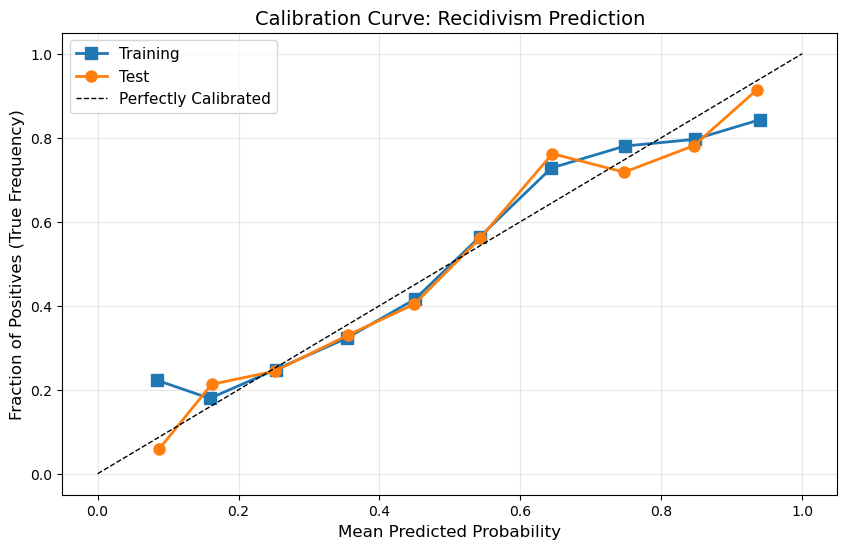

In [22]:
# Calculate calibration
prob_true_train, prob_pred_train = calibration_curve(
    y_train, y_train_proba, n_bins=10, strategy='uniform'
)
prob_true_test, prob_pred_test = calibration_curve(
    y_test, y_test_proba, n_bins=10, strategy='uniform'
)

# Plot calibration curves
plt.figure(figsize=(10, 6))
plt.plot(prob_pred_train, prob_true_train, 's-', label='Training', linewidth=2, markersize=8)
plt.plot(prob_pred_test, prob_true_test, 'o-', label='Test', linewidth=2, markersize=8)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=1)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (True Frequency)', fontsize=12)
plt.title('Calibration Curve: Recidivism Prediction', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

**How to read this:**

1. **Predictions are binned** into groups (e.g., all predictions between 0.4-0.5)
2. **X-axis:** Average predicted probability in that bin
3. **Y-axis:** Actual fraction of positives in that bin

**Perfect calibration (diagonal):**

* Bin with mean prediction 0.6 → 60% are actually positive
* Points lie on y=x line

**Above diagonal (underconfident):**

* Predicting 40% but 60% are actually positive
* Model is too conservative

**Below diagonal (overconfident):**

* Predicting 80% but only 60% are actually positive
* Model is too aggressive

### 2.6.4 Why Logistic Regression is Usually Well-Calibrated

Logistic regression directly models probabilities via MLE, so it tends to be better calibrated than many other classifiers, all else equal.

Other methods (e.g., Random Forests, SVM, Neural Networks) often produce poorly calibrated probabilities and need **calibration procedures** (Platt scaling, isotonic regression).

**Practical implications:**

* If our curve is close to diagonal → We can trust these probabilities for decision-making
* If not → We might need to recalibrate before deploying

**In criminal justice:**

Calibration is crucial for fairness. If probabilities are miscalibrated differently for different groups, we have a serious problem (we'll explore this in Part 5 on fairness).

## 2.7 Perfect Separation Problem ⚠️

**Perfect separation** occurs when the predictors (or a combination of them) can **perfectly distinguish** between the two outcome classes.

In such cases, logistic regression’s **maximum likelihood estimates do not exist** in a finite sense: the likelihood keeps increasing as coefficients grow toward ±∞.

### Why this happens

If a predictor (or linear combination of predictors) *always* separates outcomes—e.g.,

* everyone above a certain value reoffends,
* everyone below it does not—

then the model can increase certainty indefinitely by pushing coefficients larger and larger, producing probabilities arbitrarily close to 0 or 1.

### Why this is a problem

Perfect separation is not a sign of a “great” model. It usually indicates:

* **data leakage** (a variable encodes the outcome),
* **post-outcome information** included as a predictor,
* or an **overly small or unrepresentative dataset**.

In practice, it leads to:

* unstable or non-convergent estimation,
* coefficients with no meaningful interpretation,
* poor generalisation to new data.

### Warning signs to watch for

* ⚠️ Extremely large coefficients (e.g. (|\beta| \gg 10))
* ⚠️ Optimisation or convergence warnings
* ⚠️ Predicted probabilities at exactly 0 or 1
* ⚠️ Perfect (or near-perfect) training accuracy

### How to address perfect separation

1. **Inspect and remove problematic predictors**

   * Outcome proxies
   * Leaked variables
   * Post-decision information

2. **Use regularisation (Ridge / Lasso)**

   * Penalisation prevents coefficients from diverging
   * Often resolves separation while preserving predictive signal

3. **Increase data size or diversity**

   * More observations introduce overlap between classes
   * Especially important when separation arises from small samples

### Checking our model

In [23]:
# Check for warning signs in our model
print("Checking for perfect separation:")
print(f"Max absolute coefficient: {np.abs(log_reg.coef_[0]).max():.3f}")
print(f"Training accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Proportion of extreme probabilities (< 0.01 or > 0.99): {((y_train_proba < 0.01) | (y_train_proba > 0.99)).mean():.3f}")
print("\n✓ No signs of perfect separation in our model")

Checking for perfect separation:
Max absolute coefficient: 0.733
Training accuracy: 0.669
Proportion of extreme probabilities (< 0.01 or > 0.99): 0.000

✓ No signs of perfect separation in our model


**Interpretation:**
Our coefficients are moderate, probabilities are not degenerate, and training accuracy is well below 100%.
This indicates that **perfect separation is not present**, and the model estimates are well-behaved.

:::callout-note

## Demo: Perfect Separation in Practice

### Step 1: Create a perfectly separated dataset

In [24]:
# Perfectly separated toy dataset
X_sep = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 6]
})
y_sep = np.array([0, 0, 0, 1, 1, 1])

X_sep, y_sep

(   x
 0  1
 1  2
 2  3
 3  4
 4  5
 5  6,
 array([0, 0, 0, 1, 1, 1]))

There is a clean cut between the classes:
values ≤ 3 are always class 0, values ≥ 4 are always class 1.

### Step 2: Fit logistic regression *without* regularisation

In [25]:
log_reg_sep = LogisticRegression(
    penalty=None,          # no regularisation
    solver="lbfgs",
    max_iter=1000
)

log_reg_sep.fit(X_sep, y_sep)

print("Coefficient:", log_reg_sep.coef_[0][0])
print("Intercept:", log_reg_sep.intercept_[0])

Coefficient: 15.190474024227568
Intercept: -52.87345856473597


👉 You should see **very large coefficients** (often in the tens or hundreds, depending on solver behaviour).

### Step 3: Look at predicted probabilities

In [26]:
probs = log_reg_sep.predict_proba(X_sep)[:, 1]
pd.DataFrame({
    "x": X_sep["x"],
    "Predicted probability": probs
})

,x,Predicted probability
0,1,4.310104e-17
1,2,1.704617e-10
2,3,6.737103e-04
3,4,9.996251e-01
4,5,1.000000e+00
5,6,1.000000e+00


What you’ll typically observe:

* probabilities extremely close to 0 for class 0,
* probabilities extremely close to 1 for class 1,
* often *exactly* 0 or 1 up to numerical precision.

This is the model trying to enforce a vertical decision boundary.

### Step 4: Why this is a problem (key teaching moment)

Even though:

In [27]:
log_reg_sep.score(X_sep, y_sep)

1.0

returns **100% accuracy**, the model is **ill-defined**:

* coefficients are not interpretable,
* tiny data changes cause huge prediction swings,
* likelihood has no finite maximum.

This is *not* a good model — it’s a warning sign.


### Step 5: Fixing it with regularisation

Now repeat with Ridge regularisation (the default in `sklearn`):

In [28]:
log_reg_ridge = LogisticRegression(
    penalty="l2",
    C=1.0,          # regularisation strength
    solver="lbfgs"
)

log_reg_ridge.fit(X_sep, y_sep)

print("Coefficient (regularised):", log_reg_ridge.coef_[0][0])
print("Intercept (regularised):", log_reg_ridge.intercept_[0])

Coefficient (regularised): 1.1206952510393664
Intercept (regularised): -3.9223038967769632


Now:

* coefficients are finite,
* probabilities are extreme but not degenerate,
* optimisation converges cleanly.

### Visual intuition

> Under perfect separation, the sigmoid curve keeps getting steeper and steeper.
> Regularisation prevents it from becoming vertical.


### Takeaway

> Perfect separation is not a sign of a powerful model, but of a likelihood that has no finite maximum.
:::

:::callout-important

## Additional Notes on Separation

### Perfect vs. Quasi-Separation

So far we have discussed **perfect separation**, where predictors *completely* separate the two classes.

In practice, a more common situation is **quasi-separation**.

**Quasi-separation occurs when:**

* one class is *almost* perfectly separated,
* a small number of observations violate the separating rule,
* coefficients grow very large but do not technically diverge to infinity.

**What this looks like:**

* Extremely large coefficients (but finite)
* Very steep sigmoid curve
* Predicted probabilities clustered near 0 or 1
* Apparent convergence, but unstable estimates

⚠️ **Key risk:**
Quasi-separation can *look* like a valid model, but coefficient estimates may be highly sensitive to small data changes.

**Practical implication:**
Even without explicit warnings, **coefficient interpretation may be unreliable**.

### Why Separation Is More Likely in Small Samples and High Dimensions

Separation is not rare — it is a structural risk in many applied settings.

It becomes more likely when:

#### 1. Small sample sizes

With few observations, it is easier for random patterns to line up in a way that separates classes by chance.

> In small datasets, absence of overlap does not imply a strong signal — it often implies insufficient data.

#### 2. Many predictors (high dimensionality)

As the number of predictors increases, the model gains flexibility to carve the feature space into smaller regions.

With enough dimensions, it becomes easy to find a hyperplane that separates classes — even if the relationship is spurious.

This is a manifestation of the **curse of dimensionality**.

#### 3. Strong or leaked predictors

Separation often arises when predictors:

* encode the outcome directly,
* are measured after the outcome,
* or act as near-proxies for the label.

### When You Should *Not* Interpret Coefficients

You should be cautious — or avoid interpretation entirely — when you observe:

* extremely large coefficients,
* near-perfect training accuracy,
* probabilities extremely close to 0 or 1,
* signs of (quasi-)separation.

In such cases, coefficient magnitudes may reflect **data geometry**, not substantive effects.


### Logistic Regression Is Not the Only Model Affected

Although separation is most often discussed in the context of logistic regression, **the underlying issue is broader**.

Any model that:

* tries to fit a sharp decision boundary,
* optimises a likelihood or margin-based objective,
* and lacks regularisation or constraints

can exhibit unstable behaviour under separation.

Examples (we'll see some next week) include:

* unregularised linear classifiers,
* hard-margin SVMs,
* some boosting methods in small samples.

Regularisation or soft margins are common responses — but they address **symptoms**, not causes.

### Takeaway

> If the data allow near-perfect separation, the model may fit the training data extremely well — but coefficient estimates and conclusions can be misleading or meaningless.
:::

---

# Part 3: Multi-Class Classification & K-NN

### 3.1 Multi-Class Classification Task

So far, we have predicted **binary recidivism** (yes/no).
We now extend the analysis to a **multi-class classification task**, predicting the **risk category** assigned by COMPAS: **Low, Medium, or High**.

In [29]:
# Multi-class target
y_multiclass = compas_clean['score_text'].copy()

print("Risk category distribution:")
print(y_multiclass.value_counts())
print("\nProportions:")
print(y_multiclass.value_counts(normalize=True).round(3))

Risk category distribution:
score_text
Low       3122
Medium    1727
High      1301
Name: count, dtype: int64

Proportions:
score_text
Low       0.508
Medium    0.281
High      0.212
Name: proportion, dtype: float64


### 3.1.1 Encoding the Multi-Class Outcome

We encode the three risk categories numerically so they can be used by classification algorithms.

In [30]:
# Map risk categories to numeric labels
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

### 3.1.2 Reusing the Existing Train–Test Split

As in the binary classification task, we **do not create a new train–test split**.

Instead, we reuse the **same split created earlier**.
This ensures that all models in this analysis are trained and evaluated on **exactly the same individuals**, allowing meaningful comparison across tasks.

In [31]:
# Reuse existing split (same individuals as before)
X_train_mc = compas_train[X.columns]
X_test_mc  = compas_test[X.columns]

y_train_mc = compas_train['score_text'].map(risk_mapping)
y_test_mc  = compas_test['score_text'].map(risk_mapping)

print(f"Multi-class training set: {X_train_mc.shape[0]} observations")
print("\nTraining set class distribution:")
print(y_train_mc.value_counts())

Multi-class training set: 4305 observations

Training set class distribution:
score_text
0    2194
1    1202
2     909
Name: count, dtype: int64


**Why this matters:**

* Creating a new split would silently change which defendants appear in the training and test sets.
* That would make results from the binary and multi-class models **not directly comparable**.
* A single split preserves the integrity of the analytical pipeline.


### 3.1.3 Feature Scaling

Although we reuse the same split, we **re-fit the scaler** for this task.
Scaling is part of the **modeling step**, not the data split, and should be applied separately for each model.

In [32]:
# Scale features for multi-class model
scaler_mc = StandardScaler()

X_train_mc_scaled = pd.DataFrame(
    scaler_mc.fit_transform(X_train_mc),
    columns=X_train_mc.columns,
    index=X_train_mc.index
)

X_test_mc_scaled = pd.DataFrame(
    scaler_mc.transform(X_test_mc),
    columns=X_test_mc.columns,
    index=X_test_mc.index
)

:::callout-important
> **Important:**
> There should only ever be **one train–test split** for a given dataset within an analytical pipeline.
> Models may change, targets may change, and evaluation metrics may change — but the split should not.
:::

### 3.1.4 Logistic Regression for Multi-Class

Logistic regression extends to multi-class via **One-vs-Rest** (OvR) or **Multinomial** approaches.

In [33]:
# Fit multi-class logistic regression
log_reg_mc = LogisticRegression(solver='lbfgs',random_state=42, max_iter=1000)
log_reg_mc.fit(X_train_mc_scaled, y_train_mc)

# Predictions
y_train_pred_mc = log_reg_mc.predict(X_train_mc_scaled)
y_test_pred_mc = log_reg_mc.predict(X_test_mc_scaled)

# Predicted probabilities (needed for AUC / AP)
y_train_proba_mc = log_reg_mc.predict_proba(X_train_mc_scaled)
y_test_proba_mc  = log_reg_mc.predict_proba(X_test_mc_scaled)

metrics_mc = pd.DataFrame({
    "Metric": [
        "Precision (macro)",
        "Recall (macro)",
        "F1 score (macro)",
        "Balanced accuracy",
        "ROC-AUC (OvR, macro)",
        "Average precision (macro)"
    ],
    "Training": [
        precision_score(y_train_mc, y_train_pred_mc, average="macro"),
        recall_score(y_train_mc, y_train_pred_mc, average="macro"),
        f1_score(y_train_mc, y_train_pred_mc, average="macro"),
        balanced_accuracy_score(y_train_mc, y_train_pred_mc),
        roc_auc_score(y_train_mc, y_train_proba_mc, multi_class="ovr", average="macro"),
        average_precision_score(y_train_mc, y_train_proba_mc, average="macro")
    ],
    "Test": [
        precision_score(y_test_mc, y_test_pred_mc, average="macro"),
        recall_score(y_test_mc, y_test_pred_mc, average="macro"),
        f1_score(y_test_mc, y_test_pred_mc, average="macro"),
        balanced_accuracy_score(y_test_mc, y_test_pred_mc),
        roc_auc_score(y_test_mc, y_test_proba_mc, multi_class="ovr", average="macro"),
        average_precision_score(y_test_mc, y_test_proba_mc, average="macro")
    ]
})

metrics_mc["Difference"] = metrics_mc["Training"] - metrics_mc["Test"]

metrics_mc.round(3)

,Metric,Training,Test,Difference
0,Precision (macro),0.558,0.553,0.005
1,Recall (macro),0.522,0.523,-0.000
2,F1 score (macro),0.518,0.519,-0.000
3,Balanced accuracy,0.522,0.523,-0.000
4,"ROC-AUC (OvR, macro)",0.764,0.759,0.006
5,Average precision (macro),0.585,0.582,0.004


:::callout-note
**Note:**

In recent versions of `scikit-learn`, multinomial logistic regression is selected automatically when the outcome has more than two classes.
We therefore do not need to specify `multi_class='multinomial'` explicitly anymore.
:::

:::callout-important
Because the COMPAS risk categories are imbalanced, we deliberately avoid reporting raw accuracy.
Accuracy can be dominated by the majority class and may hide poor performance on less frequent risk categories.
Instead, we focus on macro-averaged precision, recall, and F1 score, balanced accuracy, and threshold-independent metrics such as ROC-AUC and Average Precision.
:::

### 3.1.3 Multi-Class Confusion Matrix

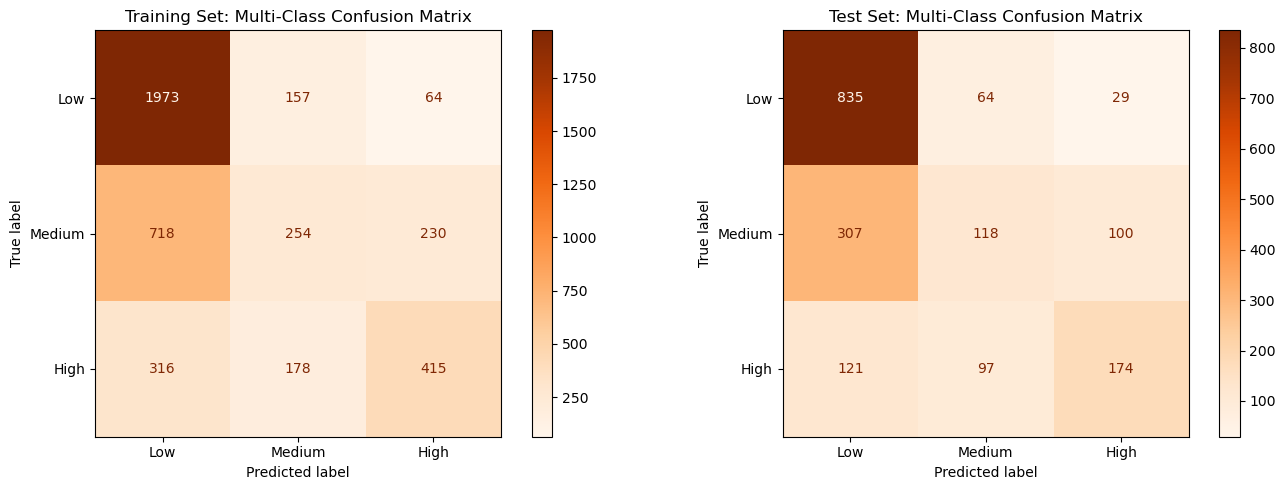

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training
ConfusionMatrixDisplay.from_predictions(
    y_train_mc, y_train_pred_mc,
    display_labels=['Low', 'Medium', 'High'],
    cmap='Oranges',
    ax=axes[0]
)
axes[0].set_title('Training Set: Multi-Class Confusion Matrix')

# Test
ConfusionMatrixDisplay.from_predictions(
    y_test_mc, y_test_pred_mc,
    display_labels=['Low', 'Medium', 'High'],
    cmap='Oranges',
    ax=axes[1]
)
axes[1].set_title('Test Set: Multi-Class Confusion Matrix')

plt.tight_layout()
plt.show()

**Key observations:**

* Diagonal = correct predictions
* Off-diagonal = misclassifications
* Are confusions symmetric (e.g., Low→Medium vs Medium→Low)?

:::callout-note

## Interpretation of Multi-Class Performance for our case study

Across all reported metrics, training and test performance are nearly identical.
This indicates that the model generalises stably to unseen data and that the patterns we observe are **structural**, not the result of overfitting.

### Risk scoring vs. risk categorisation

Multi-class logistic regression does **not** directly output Low / Medium / High labels.
Instead, for each defendant, the model first produces **predicted probabilities for each risk category**. These probabilities act as **continuous risk scores**.

Metrics such as **ROC-AUC** evaluate how well these probability scores **rank defendants by relative risk**: on average, do higher-risk defendants receive higher predicted risk scores than lower-risk defendants?

The relatively high **ROC-AUC (≈ 0.76, macro-averaged)** indicates that, at the level of these continuous scores, the model is reasonably good at ordering defendants by risk.


### From scores to labels: where performance drops

To produce a final prediction, these continuous probability scores must be converted into **discrete categories** (Low, Medium, High).
Once this happens, performance declines markedly:

* **Macro recall, balanced accuracy, and macro F1 scores are all around 0.52**, indicating substantial misclassification across classes.
* This gap between ROC-AUC and classification metrics highlights an important distinction:

  **good ranking does not guarantee good categorisation.**

### What the confusion matrices show

The confusion matrices make this distinction concrete.

**Low-risk defendants** are classified relatively well:

* Most Low-risk cases appear on the diagonal.
* Errors tend to move into the adjacent Medium category rather than directly to High.

**Medium-risk defendants** are the hardest to classify:

* Medium cases are frequently misclassified as either Low or High.
* Correct Medium classifications are comparatively rare.
* This indicates strong overlap between Medium risk and its neighbouring categories.

**High-risk defendants** are partially identified but often downgraded:

* Some High-risk cases are correctly classified.
* Many are misclassified as Medium or even Low, reducing recall for the High-risk class.

Importantly, errors are **not random**. They are concentrated around the **boundaries between adjacent risk categories**, rather than between extreme categories.

### Connecting metrics and matrices

* **ROC-AUC** reflects performance at the level of **continuous probability scores**, before category boundaries are imposed.
* **Balanced accuracy and macro-averaged metrics** reflect performance after forcing those scores into discrete labels.
* The discrepancy between these metrics shows that the model captures relative risk reasonably well, but struggles to learn clear boundaries between overlapping risk groups.

### Key takeaway

> The model assigns meaningful continuous risk scores that allow it to rank defendants by relative risk, but substantial overlap between Low, Medium, and High risk groups makes accurate assignment to discrete categories—especially Medium and High—difficult.
:::

:::callout-note
### Illustrative examples: ranking vs. categorisation

To see the difference between **risk ranking** and **risk categorisation**, consider two simplified examples based on predicted probabilities.

#### Example 1: Good ranking, ambiguous categories

Suppose the model produces the following predicted probabilities:

| Defendant | P(Low) | P(Medium) | P(High) |
| --------- | ------ | --------- | ------- |
| A         | 0.60   | 0.30      | 0.10    |
| B         | 0.40   | 0.35      | 0.25    |
| C         | 0.25   | 0.40      | 0.35    |

From these probabilities, the model **clearly ranks risk**:

* A is lowest risk
* B is intermediate
* C is highest risk

This ordering is exactly what ROC-AUC evaluates: higher-risk defendants tend to receive higher predicted risk scores than lower-risk ones.

However, when we assign **hard class labels** using the highest probability:

* A → Low
* B → Low (despite substantial Medium and High probabilities)
* C → Medium

Here, B and C may be **misclassified**, even though the relative ordering of risk makes sense.
The problem is not ranking, but the **forced category boundaries**.

#### Example 2: Why Medium risk is hardest

Now consider two defendants whose true category is Medium:

| Defendant | P(Low) | P(Medium) | P(High) |
| --------- | ------ | --------- | ------- |
| D         | 0.38   | 0.41      | 0.21    |
| E         | 0.34   | 0.36      | 0.30    |

Both defendants have **very similar probability mass spread across categories**.

* Small changes in the data could flip D to Low
* Small changes could flip E to High

This explains what we see in the confusion matrix:

* Medium-risk cases are frequently misclassified
* Errors tend to go to **adjacent categories**, not randomly

The model is uncertain because the **feature distributions for Medium risk overlap strongly** with both Low and High.

#### Example 3: Connecting back to the metrics

* **ROC-AUC** rewards the fact that C is ranked above B, and B above A
* **Balanced accuracy and macro F1** penalise the incorrect class assignments for B and C
* The confusion matrix shows these errors explicitly

So all three views are consistent — they are simply measuring **different stages of the prediction process**.

### One-sentence intuition

> The model often knows *who is riskier than whom*, but not *exactly where one risk category ends and the next begins*.
:::

## 3.2 K-Nearest Neighbors (K-NN): Classification by Similarity

### 3.2.1 A Completely Different Approach

So far we've used **parametric** methods (logistic regression):

* **Learn parameters** (coefficients β) from training data
* **Make predictions** using those fixed parameters
* **Discard** training data after learning

K-NN is **non-parametric**:

* **No training phase**—just store the data
* **Make predictions** by looking up similar examples
* **Keep** all training data in memory

This is called "instance-based" or "memory-based" learning.

### 3.2.2 The K-NN Algorithm (Intuition)

Imagine you're a judge deciding on bail. K-NN's logic:

1. **Look at the defendant's characteristics** (age, priors, charge type)
2. **Find K most similar past cases** (closest in feature space)
3. **See what happened to them** (did they reoffend?)
4. **Take a vote:** If most of the K neighbors reoffended → predict recidivism

**Core assumption:** Similar people behave similarly.

Another example (**images and example from [here](https://www.analyticsvidhya.com/blog/2018/03/introduction-k-neighbours-algorithm-clustering/):**):

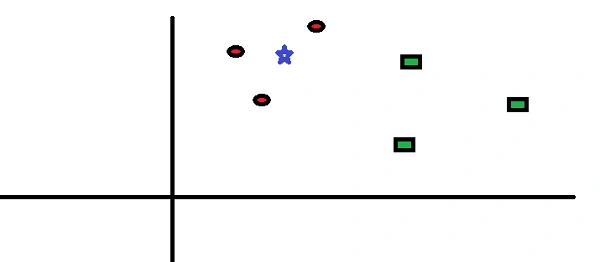

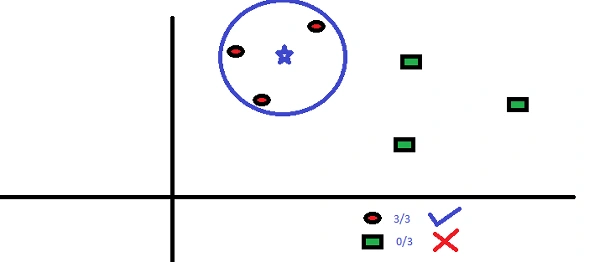

### 3.2.3 How K-NN Works (Formal)

**For classification:**

1. Choose K (number of neighbors to consider)
2. For a new observation $x_{new}$:
   * Calculate distance to all training observations
   * Find K closest neighbors
   * Take majority vote of their labels
   * Predict the most common class

**Distance metric** (typically Euclidean):

$$
d(x_i, x_j) = \sqrt{\sum_{p=1}^P (x_{ip} - x_{jp})^2}
$$

**Why feature scaling matters:**

Without scaling, features with larger ranges dominate distance calculations!

Example:

* Age: 20-70 (range 50)
* Priors: 0-30 (range 30)
* Age differences swamp prior differences

After scaling (standardization), all features contribute equally.

### 3.2.4 K-NN for Binary Classification

In [35]:
# Fit K-NN with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_knn = knn.predict(X_train_scaled)
y_test_pred_knn = knn.predict(X_test_scaled)

# Compare to logistic regression
print("K-NN (K=5) vs Logistic Regression:\n")
print(f"{'Metric':<20} {'K-NN Train':<15} {'K-NN Test':<15} {'LogReg Train':<15} {'LogReg Test':<15}")
print("-" * 65)

knn_metrics = {
    'Accuracy': [
        accuracy_score(y_train, y_train_pred_knn),
        accuracy_score(y_test, y_test_pred_knn),
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_train, y_train_pred_knn),
        balanced_accuracy_score(y_test, y_test_pred_knn),
        balanced_accuracy_score(y_train, y_train_pred),
        balanced_accuracy_score(y_test, y_test_pred)
    ],
    'Precision': [
        precision_score(y_train, y_train_pred_knn),
        precision_score(y_test, y_test_pred_knn),
        precision_score(y_train, y_train_pred),
        precision_score(y_test, y_test_pred)
    ],
    'Recall': [
        recall_score(y_train, y_train_pred_knn),
        recall_score(y_test, y_test_pred_knn),
        recall_score(y_train, y_train_pred),
        recall_score(y_test, y_test_pred)
    ]
}

for metric, scores in knn_metrics.items():
    print(f"{metric:<20} {scores[0]:<15.3f} {scores[1]:<15.3f} {scores[2]:<15.3f} {scores[3]:<15.3f}")

K-NN (K=5) vs Logistic Regression:

Metric               K-NN Train      K-NN Test       LogReg Train    LogReg Test    
-----------------------------------------------------------------
Accuracy             0.725           0.626           0.669           0.672          
Balanced Accuracy    0.720           0.622           0.664           0.668          
Precision            0.728           0.608           0.661           0.660          
Recall               0.652           0.558           0.593           0.608          


**Key observation:**

K-NN often has **much higher training accuracy** than logistic regression.

**Why?**

* K-NN is extremely flexible (can fit complex patterns)
* For K=1, training accuracy ≈ 100% (each point is its own nearest neighbor!)
* But this doesn't mean it's better—it might be overfitting

**Test performance reveals the truth** about generalization.

:::callout-note

### K-NN vs Logistic regression in our case study

The key pattern in the results is the gap between training and test performance for K-NN, compared to the near-identical performance of logistic regression.

For K-NN, all metrics drop substantially from training to test:

- Accuracy: 0.725 → 0.626

- Balanced accuracy: 0.720 → 0.622

- Precision: 0.728 → 0.608

- Recall: 0.652 → 0.558

This indicates that K-NN fits the training data very well, but that much of this apparent performance does not generalise to unseen data.

For logistic regression, training and test performance are nearly identical across all metrics, indicating a model that generalises much more reliably.

This contrast is a classic example of overfitting, which can be understood through the lens of bias and variance.
:::

::: callout-tip

### Why K-NN Overfits and Logistic Regression Doesn’t

*(Bias–Variance Intuition, with Analogies)*

To understand the difference between K-NN and logistic regression, it helps to think in terms of **bias** and **variance**. These describe *how* a model learns from data.


#### Bias: error from overly simple assumptions

**Bias** refers to how strongly a model constrains the relationship between predictors and the outcome.

* A **high-bias** model is rigid and makes strong simplifying assumptions.
* It may fail to capture important patterns in the data.
* Its predictions tend to be **stable** across different samples.

**Analogy (high bias):**
A student who studies only broad principles and ignores details.
They may perform consistently across exams, but often miss important points.

**In our comparison:**
Logistic regression has **higher bias** because it assumes a simple, global relationship between predictors and the outcome.


#### Variance: error from sensitivity to the data

**Variance** refers to how much a model’s predictions change when the training data change slightly.

* A **high-variance** model adapts very closely to the training data.
* Small quirks or noise can strongly influence predictions.
* This often leads to **overfitting**.

**Analogy (high variance):**
A student who memorises past exam questions word for word.
They perform very well on familiar questions, but struggle when questions change.

**In our comparison:**
K-NN has **high variance** because it makes predictions based on local neighbourhoods in the training data.

#### Important clarification: low variance is not enough

Having **low variance** does *not* automatically mean good generalisation.

A model with **very high bias and very low variance** can generalise *consistently* — but consistently **badly**.
This is called **underfitting**.

**Analogy (extreme bias):**
A student who memorises a single sentence and uses it to answer every question.
Their answers are stable, but almost always wrong.

#### The bias–variance trade-off

Most models balance bias and variance:

* Increasing flexibility ↓ bias but ↑ variance
* Increasing constraints ↑ bias but ↓ variance

The goal is **not** to minimise bias or variance individually, but to find a balance that leads to good generalisation.

#### Connecting this to our results

* **K-NN**

  * Low bias, high variance
  * High training performance
  * Large drop on test data → **overfitting**

* **Logistic regression**

  * Higher bias, low variance
  * Similar training and test performance → **better generalisation**

**Key takeaway:**
K-NN overfits because its variance is too high for this dataset, while logistic regression generalises better because it achieves a more appropriate bias–variance balance.
:::




### 3.2.5 The Curse of Dimensionality

K-NN has a fundamental limitation: it struggles in **high dimensions**.

**Why?**

In high dimensions, all points become roughly equidistant:

* With many features, "nearest" neighbors aren't actually very near
* Need exponentially more data to maintain density

**Rule of thumb:** K-NN works well with <10-20 features, struggles beyond that.

Logistic regression doesn't have this problem (can handle many features).

### 3.2.6 Effect of K on Performance

The choice of K creates a bias-variance trade-off:

**Small K (e.g., K=1):**

* **More flexible** → captures local patterns
* **High variance** → sensitive to noise (overfitting risk)
* **Decision boundaries** very wiggly

**Large K (e.g., K=50):**

* **Smoother** → averages over many neighbors
* **High bias** → misses local patterns (underfitting risk)
* **Decision boundaries** smooth

Let's see this empirically:

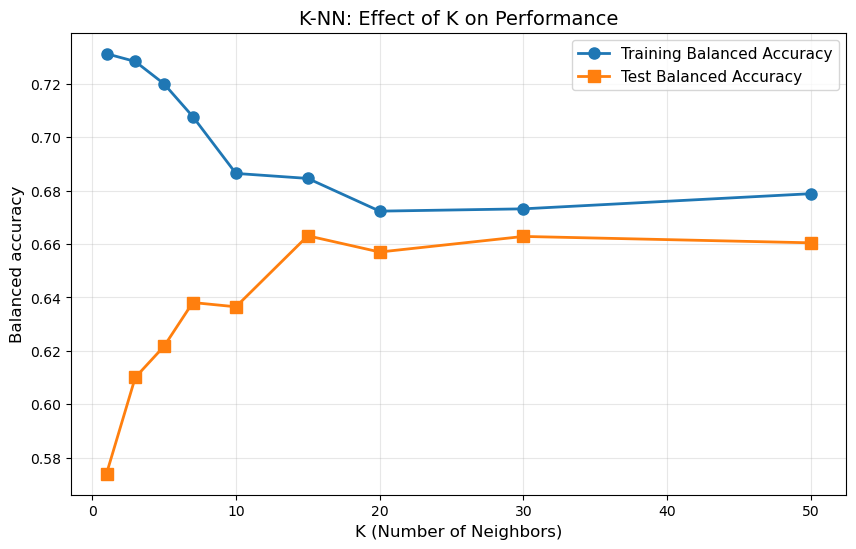


Best K on test set: 15 (balanced accuracy = 0.663)


In [36]:
# Try different K values
k_values = [1, 3, 5, 7, 10, 15, 20, 30, 50]
train_scores = []
test_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    
    train_scores.append(balanced_accuracy_score(y_train, knn_k.predict(X_train_scaled)))
    test_scores.append(balanced_accuracy_score(y_test, knn_k.predict(X_test_scaled)))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Training Balanced Accuracy', linewidth=2, markersize=8)
plt.plot(k_values, test_scores, 's-', label='Test Balanced Accuracy', linewidth=2, markersize=8)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Balanced accuracy', fontsize=12)
plt.title('K-NN: Effect of K on Performance', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# Find best K
best_k_idx = np.argmax(test_scores)
best_k = k_values[best_k_idx]
print(f"\nBest K on test set: {best_k} (balanced accuracy = {test_scores[best_k_idx]:.3f})")

**What we see:**

* **K=1:** Very high training balanced accuracy (nearly perfect), but worse test balanced accuracy
  * Memorizing training data

* **K increases:** Training balanced accuracy decreases (less flexible)
  * Test balanced accuracy first improves (less overfitting)
  * Then gets worse (too much smoothing)

* **Optimal K:** Balances bias and variance

**The U-shaped test error curve** is characteristic of the bias-variance trade-off!

# Part 4: Resampling Methods & Hyperparameter Tuning

## 4.1 The Validation Problem

When we evaluate a model on a single test set:

1. **High variance:** Performance varies based on which observations are in test set
2. **Data waste:** Test set isn't used for training

**Solution:** Resampling methods use training data more efficiently.

## 4.2 K-Fold Cross-Validation: Better Performance Estimates

### 4.2.1 The Core Idea

Instead of one arbitrary train-test split, **systematically rotate** which observations serve as validation.

**Process:**

1. **Divide data into K equal-sized folds** (typically K=5 or K=10)
2. **For each fold k = 1 to K:**
   * Use fold k as validation set
   * Use folds 1, 2, ..., k-1, k+1, ..., K as training set
   * Fit model and evaluate
3. **Average the K performance estimates**

**Visual example (5-fold CV):**

```
Iteration 1: [Test][Train][Train][Train][Train]
Iteration 2: [Train][Test][Train][Train][Train]
Iteration 3: [Train][Train][Test][Train][Train]
Iteration 4: [Train][Train][Train][Test][Train]
Iteration 5: [Train][Train][Train][Train][Test]
```

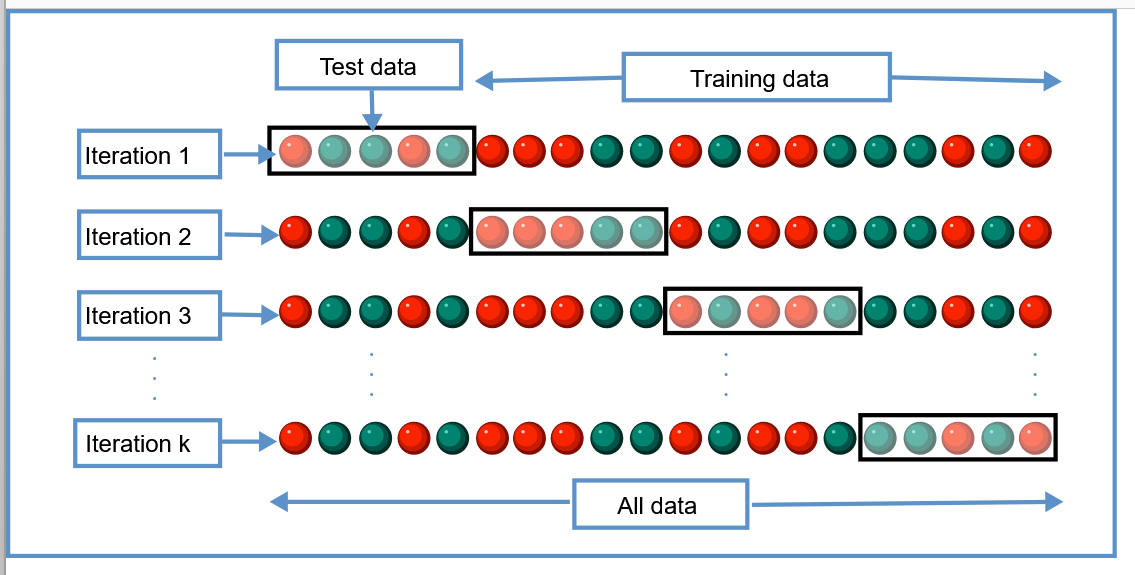

*Image from [https://upload.wikimedia.org/wikipedia/commons/b/b5/K-fold_cross_validation_EN.svg](https://upload.wikimedia.org/wikipedia/commons/b/b5/K-fold_cross_validation_EN.svg)*

Every observation is used for:

* **Training:** K-1 times
* **Validation:** 1 time

### 4.2.2 Why Cross-Validation is Better

**Problem with single split:**

* Performance estimate depends on **random luck** of which observations ended up in test set
* Might get unusually easy or hard test set
* High variance in the estimate

**How CV helps:**

* Averages over K different validation sets
* **Lower variance** in performance estimate
* More **stable** and **reliable** measure of generalization

**Analogy:**

Single train-test split = taking one exam
Cross-validation = taking K exams and averaging the scores

Which gives a better measure of true ability?

### 4.2.3 Implementing Cross-Validation

In [37]:
# 5-fold cross-validation for logistic regression
cv_scores = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='balanced_accuracy'
)

print("5-Fold Cross-Validation Results:")
print(f"Fold balanced_accuracy: {cv_scores.round(3)}")
print(f"Mean CV balanced_accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"Compare to single test set balanced_accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

5-Fold Cross-Validation Results:
Fold balanced_accuracy: [0.662 0.64  0.654 0.69  0.677]
Mean CV balanced_accuracy: 0.665 (+/- 0.018)
Compare to single test set balanced_accuracy: 0.668


**What do we learn?**

* **Mean CV score:** Best estimate of expected performance on new data
* **Standard deviation:** Indicates variability/stability
  * Low std → stable performance across folds
  * High std → performance varies (might indicate overfitting or data issues)

### 4.2.4 Stratified K-Fold: Essential for Classification

**The problem with regular K-fold:**

Random splits might create imbalanced folds. Example:

* Dataset: 60% class 0, 40% class 1
* By chance, one fold might have 80% class 0 (!)
* Model trained on other folds sees different distribution
* Performance estimates become unreliable

**Stratified K-fold solution:**

Ensures each fold has approximately the **same class distribution** as the full dataset.

**How it works:**

1. Sort observations by class
2. Distribute them across folds in round-robin fashion
3. Each fold has ~60% class 0, ~40% class 1

In [38]:
# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_stratified = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'  # Better for imbalanced data
)

print("Stratified 5-Fold CV (Balanced Accuracy):")
print(f"Fold scores: {cv_scores_stratified.round(3)}")
print(f"Mean: {cv_scores_stratified.mean():.3f} (+/- {cv_scores_stratified.std():.3f})")

Stratified 5-Fold CV (Balanced Accuracy):
Fold scores: [0.663 0.672 0.667 0.675 0.644]
Mean: 0.664 (+/- 0.011)


**Best practice:** Always use stratified CV for classification.

### 4.2.5 Choosing K

**Trade-offs:**

* **Larger K (e.g., K=10):**
  * ✓ More training data per fold (K-1)/K of full dataset)
  * ✓ Lower bias in performance estimate
  * ✗ Higher computational cost (fit K models)
  * ✗ Folds are more similar → higher variance in estimate

* **Smaller K (e.g., K=5):**
  * ✓ Faster (fewer models to fit)
  * ✓ Folds more independent → lower variance
  * ✗ Less training data per fold
  * ✗ Higher bias

**Common choices:**

* **K=5:** Good default for most problems
* **K=10:** When you have enough data and computation time
* **Leave-One-Out (K=n):** Maximum training data, but very expensive and high variance

**For this course:** K=5 is a sensible default.

Bu how do we actually choose K in a principled way?

## 4.3 Hyperparameter Tuning with Grid Search

**Hyperparameters** are model settings we choose (not learned from data):

* Logistic Regression: regularization strength `C`, penalty type (`l1`, `l2`)
* K-NN: number of neighbors `K`

**Grid Search** tries all combinations in a grid:

In [39]:
# Define parameter grid for logistic regression
param_grid_lr = {
    'C': [0.01,0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# Grid search with 5-fold CV
grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=500),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_lr.best_params_}")
print(f"Best CV score: {grid_search_lr.best_score_:.3f}")

# Evaluate best model on test set
best_lr = grid_search_lr.best_estimator_
y_test_pred_best = best_lr.predict(X_test_scaled)

print(f"\nTest set performance with best parameters:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred_best):.3f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_best):.3f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.664

Test set performance with best parameters:
Balanced Accuracy: 0.668
F1 Score: 0.633


### 4.3.1 Grid Search for K-NN

In [40]:
# Parameter grid for K-NN
param_grid_knn = {
    'n_neighbors': [3, 5, 10, 20],
    'weights': ['uniform', 'distance']
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train_scaled, y_train)

print(f"\nBest KNN parameters: {grid_search_knn.best_params_}")
print(f"Best CV score: {grid_search_knn.best_score_:.3f}")

# Test set evaluation
best_knn = grid_search_knn.best_estimator_
y_test_pred_knn_best = best_knn.predict(X_test_scaled)

print(f"\nTest set performance with best KNN:")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred_knn_best):.3f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_knn_best):.3f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best KNN parameters: {'n_neighbors': 20, 'weights': 'uniform'}
Best CV score: 0.651

Test set performance with best KNN:
Balanced Accuracy: 0.657
F1 Score: 0.596


## 4.4 Comparing Models

In [41]:
# Summary comparison
models = {
    'Logistic Regression (default)': log_reg,
    'Logistic Regression (tuned)': best_lr,
    'K-NN (K=5)': knn,
    'K-NN (tuned)': best_knn
}

comparison = []
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Balanced Acc': balanced_accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })

comparison_df = pd.DataFrame(comparison).set_index('Model')
print("Model Comparison on Test Set:")
print(comparison_df.round(3))

Model Comparison on Test Set:
                               Accuracy  Balanced Acc  Precision  Recall  \
Model                                                                      
Logistic Regression (default)     0.672         0.668      0.660   0.608   
Logistic Regression (tuned)       0.672         0.668      0.660   0.608   
K-NN (K=5)                        0.626         0.622      0.608   0.558   
K-NN (tuned)                      0.666         0.657      0.682   0.530   

                                  F1  
Model                                 
Logistic Regression (default)  0.633  
Logistic Regression (tuned)    0.633  
K-NN (K=5)                     0.582  
K-NN (tuned)                   0.596  


:::callout-note

### Interpreting the Grid Search Results

#### What does “Fitting 5 folds for each of *k* candidates” mean?

**Logistic regression**

> *Fitting 5 folds for each of 4 candidates, totalling 20 fits*

* You evaluated **4 different values of `C`**
* Each value was evaluated using **5-fold cross-validation**
* Total models trained = (4 \times 5 = 20)

**K-NN**

> *Fitting 5 folds for each of 8 candidates, totalling 40 fits*

* You evaluated **8 hyperparameter combinations**
* Each evaluated with **5-fold cross-validation**
* Total models trained = (8 \times 5 = 40)

So CV is repeatedly training the model on slightly different subsets of the **training data only** to estimate out-of-sample performance.

#### Logistic Regression: What do the numbers say?

**Best parameters**

```text
C = 1
```

* This corresponds to **moderate regularisation**
* Neither very strong shrinkage (small `C`) nor near-unregularised (large `C`)
* Suggests the signal in the predictors is real but not extreme

**Performance comparison**

| Metric            | CV    | Test  |
| ----------------- | ----- | ----- |
| Balanced Accuracy | 0.664 | 0.668 |
| F1 score          | —     | 0.633 |

**Interpretation**

* CV and test performance are **very close**
* Test performance is *slightly higher*, which can happen due to sampling variability
* This indicates:

  * **Stable generalisation**
  * No evidence of overfitting
  * CV provided a reliable estimate of real-world performance

In short: **logistic regression is behaving exactly as we’d hope.**

#### K-NN: What do the numbers say?

**Best parameters**

```text
n_neighbors = 20
weights = 'uniform'
```

* A **large `k`** means:

  * Each prediction averages over many neighbours
  * Smoother decision boundaries
  * Reduced variance compared to small-k KNN
* Uniform weights suggest distance weighting did not help here

**Performance comparison**

| Metric            | CV    | Test  |
| ----------------- | ----- | ----- |
| Balanced Accuracy | 0.651 | 0.657 |
| F1 score          | —     | 0.596 |

**Interpretation**

* CV and test scores are again **very close**
* Generalisation is stable, but:

  * Overall performance is **worse than logistic regression**
  * Especially in F1 (weaker precision–recall balance)

This tells us that:

* Even after tuning, **KNN struggles more** with this dataset
* Likely due to:

  * Feature overlap between classes
  * Curse of dimensionality
  * Less robust decision boundaries than logistic regression

#### Comparing the two models

**Key takeaway**

| Model               | CV BA | Test BA | Stability   | Overall  |
| ------------------- | ----- | ------- | ----------- | -------- |
| Logistic Regression | 0.664 | 0.668   | Very stable | ✅ Better |
| K-NN                | 0.651 | 0.657   | Stable      | ❌ Weaker |

* Logistic regression:

  * Generalises well
  * Outperforms KNN
  * Easier to interpret
* KNN:

  * No longer overfitting after tuning
  * But still underperforms
:::

::: callout-tip
### Uniform weights in K-Nearest Neighbours

With `weights = 'uniform'`, **all $k$ nearest neighbours contribute equally** to the prediction.

- Each neighbour gets the same weight
- The prediction is based on a **simple majority vote**
- Distance is used **only to decide who the neighbours are**, not how influential they are

**Example (classification):**

If $k = 5$ and among the 5 nearest neighbours:
- 3 belong to class A  
- 2 belong to class B  

→ The model predicts **class A**, regardless of how close or far those neighbours are.

**Contrast:**  
With `weights = 'distance'`, closer neighbours have more influence, and distant ones count less.

**Why uniform weights may work better here:**

- Less sensitive to noisy distance measurements
- Produces smoother decision boundaries
- Often more stable when features overlap substantially
:::


:::callout-note

### 📌Comparing cross-validation and test set performance

Cross-validation scores estimate how a model is expected to perform on unseen data during model selection.

Test set scores measure performance on a completely held-out dataset after all tuning decisions are made.

How to interpret the comparison:

- CV ≈ Test → Good generalisation, stable model

- CV >> Test → Overfitting (model looked good during tuning but fails on new data)

- CV << Test → Usually harmless sampling noise, but worth noting

Best practice:

- Use CV metrics to choose hyperparameters

- Use test metrics only once, at the very end

- Never tune models based on test performance

If CV and test metrics align closely—as they do here—you can be confident in your conclusions.
:::

---

# Part 5: Algorithmic Fairness ⚖️

## 5.1 Why Fairness Matters

Machine learning models are used in high-stakes decisions:

* Criminal justice (bail, sentencing, parole)
* Hiring and employment
* Lending and credit
* Healthcare resource allocation

When models exhibit bias, they can perpetuate or amplify societal inequalities, especially affecting protected groups (race, gender, age).

In the COMPAS context, fairness is especially salient because predictions are used to justify differential treatment under conditions of unequal social and legal constraints.

## 5.2 Three Fairness Definitions

Fairness can be defined in many different ways.

These fairness definitions answer different ethical questions.
They are not interchangeable, and—when groups differ in underlying outcome rates—they cannot all be satisfied at the same time.

**Important:** These definitions are often **mathematically incompatible** when base rates differ between groups.

### 5.2.1 Demographic Parity (Statistical Parity)

**Definition:** Probability of positive prediction should be equal across groups.

$$
P(\hat{Y}=1 | A=a) = P(\hat{Y}=1 | A=b)
$$

**Example:** 40% of Black defendants predicted high-risk → 40% of White defendants should also be predicted high-risk.

**Focuses on:** Equality of treatment (same positive prediction rate)

### 5.2.2 Equalized Odds (Error Rate Balance)

**Definition:** True positive rate AND false positive rate should be equal across groups.

$$
P(\hat{Y}=1 | Y=1, A=a) = P(\hat{Y}=1 | Y=1, A=b) \quad \text{[Equal TPR]}
$$
$$
P(\hat{Y}=1 | Y=0, A=a) = P(\hat{Y}=1 | Y=0, A=b) \quad \text{[Equal FPR]}
$$

**Example:** Among those who reoffend, model flags Black and White defendants at same rate. Among those who don't reoffend, false alarm rates are also equal.

**Focuses on:** Equality of error rates

**This is what ProPublica argued COMPAS violated.**

### 5.2.3 Predictive Parity (Calibration)

**Definition:** Among those predicted positive, probability of actually being positive should be equal across groups.

$$
P(Y=1 | \hat{Y}=1, A=a) = P(Y=1 | \hat{Y}=1, A=b)
$$

**Example:** If model predicts high-risk, that prediction should be equally accurate for Black and White defendants.

**Focuses on:** Equality of predictive accuracy

**This is what Northpointe argued COMPAS satisfied.**

## 5.3 Fairness Evaluation on COMPAS Data

Let's evaluate our logistic regression model across racial groups.

In [42]:
# Get predictions for test set with race information
test_with_race = compas_test.copy()
test_with_race['y_pred'] = y_test_pred
test_with_race['y_proba'] = y_test_proba

# Separate by race
black_test = test_with_race[test_with_race['race'] == 'African-American']
white_test = test_with_race[test_with_race['race'] == 'Caucasian']

print(f"Test set size: {len(test_with_race)}")
print(f"Black defendants: {len(black_test)}")
print(f"White defendants: {len(white_test)}")

Test set size: 1845
Black defendants: 1101
White defendants: 744


### 5.3.1 Base Rates

In [43]:
# Check if base rates differ (recidivism rates)
base_rate_black = black_test[target_col].mean()
base_rate_white = white_test[target_col].mean()

print("Base Rates (Actual Recidivism):")
print(f"Black defendants: {base_rate_black:.3f}")
print(f"White defendants: {base_rate_white:.3f}")
print(f"Difference: {base_rate_black - base_rate_white:.3f}")

if abs(base_rate_black - base_rate_white) > 0.05:
    print("\n⚠️ Base rates differ substantially → Impossibility theorems apply")
    print("   Cannot satisfy all fairness definitions simultaneously!")

Base Rates (Actual Recidivism):
Black defendants: 0.515
White defendants: 0.394
Difference: 0.121

⚠️ Base rates differ substantially → Impossibility theorems apply
   Cannot satisfy all fairness definitions simultaneously!


The base rate is the **actual outcome frequency** in each group.
Here, Black defendants reoffend at a substantially higher observed rate than White defendants in the dataset.

At this stage, we do **not** attempt to explain why these base rates differ.
The key point is that **they do differ**, and this fact alone constrains what fairness criteria can be satisfied.

::: callout-warning
### Why differing base rates change everything

When groups have different base rates for the outcome:

- Equal positive prediction rates (demographic parity)
- Equal error rates (equalized odds)
- Equal predictive accuracy (predictive parity)

**cannot all hold at once** for a non-trivial classifier.

This is not a modelling failure — it is a mathematical constraint.

(It's called the fairness impossibility theorem!)

Any model that predicts better than random must trade off between these fairness notions.
:::

:::callout-tip
### Why differing base rates force trade-offs

Suppose we have **1,000 defendants** in each group.

#### Step 1: Different base rates (the only assumption)

Assume the observed recidivism rates are:

* **Black defendants:** 50% reoffend → 500 out of 1,000
* **White defendants:** 30% reoffend → 300 out of 1,000

Nothing about modelling yet — this is just the data.

#### Case A: Try to satisfy **predictive parity** (equal accuracy when flagged)

Suppose the model predicts **“high risk”** for:

* 400 Black defendants
* 200 White defendants

And suppose predictive parity holds with **precision = 70%** for both groups.

That means:

**Black defendants**

* 400 flagged as high risk
* 70% actually reoffend → **280 true positives**
* 30% do not → **120 false positives**

**White defendants**

* 200 flagged as high risk
* 70% actually reoffend → **140 true positives**
* 30% do not → **60 false positives**

✅ Predictive parity holds
❌ But now look at error rates:

* Black FPR = 120 / 500 non-reoffenders = **24%**
* White FPR = 60 / 700 non-reoffenders = **8.6%**

➡️ **False positive rates differ sharply**
➡️ **Equalized odds is violated**

#### Case B: Try to satisfy **equalized odds** instead

Now suppose we force:

* False positive rate = 10% for both groups
* True positive rate = 60% for both groups

Let’s compute what that implies.

**Black defendants**

* True positives = 60% of 500 = **300**
* False positives = 10% of 500 = **50**
* Total flagged = **350**

Precision = 300 / 350 ≈ **86%**

**White defendants**

* True positives = 60% of 300 = **180**
* False positives = 10% of 700 = **70**
* Total flagged = **250**

Precision = 180 / 250 = **72%**

✅ Equalized odds holds
❌ Predictive parity fails (precision differs)

#### Case C: Try to satisfy **demographic parity**

Now suppose we force **equal positive prediction rates**:

* 300 Black defendants flagged
* 300 White defendants flagged

Given different base rates, the composition must differ.

Even if the model is doing its best:

* The flagged Black group will contain **more true positives**
* The flagged White group will contain **more false positives**

So either:

* precision differs, or
* error rates differ, or
* both

➡️ Demographic parity cannot coexist with the other criteria.

### The unavoidable conclusion

Once base rates differ:

* **Equal precision** ⇒ unequal error rates
* **Equal error rates** ⇒ unequal precision
* **Equal prediction rates** ⇒ unequal accuracy

There is no way to make the same people:

* be flagged at the same rate,
* make the same kinds of mistakes,
* and have predictions be equally reliable,

**all at once**.

### Why this is not a modelling failure

Nothing above depends on:

* the algorithm,
* the loss function,
* optimisation,
* or bias in training.

The conflict comes from **conditioning on different quantities** when group outcome frequencies differ.

That’s why fairness debates are about **which error you are willing to tolerate**, not about “fixing” the model.


> When groups differ in how often the outcome occurs, you cannot make predictions that are equally frequent, equally wrong, and equally accurate at the same time.

:::


### 5.3.2 Demographic Parity Check

In [44]:
# Positive prediction rates
ppr_black = black_test['y_pred'].mean()
ppr_white = white_test['y_pred'].mean()

print("\nDemographic Parity:")
print(f"Black defendants predicted to reoffend: {ppr_black:.3f}")
print(f"White defendants predicted to reoffend: {ppr_white:.3f}")
print(f"Difference: {ppr_black - ppr_white:.3f}")

if abs(ppr_black - ppr_white) < 0.05:
    print("✓ Approximately satisfies demographic parity")
else:
    print("✗ Violates demographic parity")


Demographic Parity:
Black defendants predicted to reoffend: 0.530
White defendants predicted to reoffend: 0.280
Difference: 0.251
✗ Violates demographic parity


The model predicts recidivism for Black defendants at **nearly twice** the rate of White defendants.

This violates demographic parity because the **decision rate itself** differs sharply across groups.

This result largely mirrors the difference in base rates: a model that responds to underlying outcome differences will generally produce unequal positive prediction rates.

### 5.3.3 Equalized Odds Check

In [45]:
from sklearn.metrics import confusion_matrix

# Calculate TPR and FPR for each group
def calculate_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return tpr, fpr

tpr_black, fpr_black = calculate_rates(black_test[target_col], black_test['y_pred'])
tpr_white, fpr_white = calculate_rates(white_test[target_col], white_test['y_pred'])

print("\nEqualized Odds:")
print(f"True Positive Rate (Recall):")
print(f"  Black: {tpr_black:.3f}")
print(f"  White: {tpr_white:.3f}")
print(f"  Difference: {tpr_black - tpr_white:.3f}")

print(f"\nFalse Positive Rate:")
print(f"  Black: {fpr_black:.3f}")
print(f"  White: {fpr_white:.3f}")
print(f"  Difference: {fpr_black - fpr_white:.3f}")

if abs(tpr_black - tpr_white) < 0.05 and abs(fpr_black - fpr_white) < 0.05:
    print("\n✓ Approximately satisfies equalized odds")
else:
    print("\n✗ Violates equalized odds")


Equalized Odds:
True Positive Rate (Recall):
  Black: 0.688
  White: 0.454
  Difference: 0.234

False Positive Rate:
  Black: 0.363
  White: 0.166
  Difference: 0.197

✗ Violates equalized odds


Equalized odds fails in two ways:

- Black defendants who reoffend are more likely to be correctly flagged (higher TPR)

- Black defendants who do not reoffend are also more likely to be falsely flagged (higher FPR)

This asymmetry implies a higher burden of **false alarms** for Black defendants, a central concern in the ProPublica critique of COMPAS.

### 5.3.4 Predictive Parity Check

In [46]:
# Precision (PPV) for each group
def calculate_precision(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fp) if (tp + fp) > 0 else 0

prec_black = calculate_precision(black_test[target_col], black_test['y_pred'])
prec_white = calculate_precision(white_test[target_col], white_test['y_pred'])

print("\nPredictive Parity (Precision/PPV):")
print(f"Black defendants: {prec_black:.3f}")
print(f"White defendants: {prec_white:.3f}")
print(f"Difference: {prec_black - prec_white:.3f}")

if abs(prec_black - prec_white) < 0.05:
    print("✓ Approximately satisfies predictive parity")
else:
    print("✗ Violates predictive parity")


Predictive Parity (Precision/PPV):
Black defendants: 0.668
White defendants: 0.639
Difference: 0.028
✓ Approximately satisfies predictive parity


Predictive parity is approximately satisfied: when the model predicts recidivism, it is similarly accurate for Black and White defendants.

This comes at the cost of violating both demographic parity and equalized odds.
Achieving equal predictive accuracy requires allowing different error rates when base rates differ.

### 5.3.5 Summary Table

In [47]:
fairness_summary = pd.DataFrame({
    'Metric': ['Base Rate (Actual Recid)', 'Positive Prediction Rate', 
               'True Positive Rate (Recall)', 'False Positive Rate', 
               'Precision (PPV)'],
    'Black Defendants': [base_rate_black, ppr_black, tpr_black, fpr_black, prec_black],
    'White Defendants': [base_rate_white, ppr_white, tpr_white, fpr_white, prec_white],
    'Difference': [
        base_rate_black - base_rate_white,
        ppr_black - ppr_white,
        tpr_black - tpr_white,
        fpr_black - fpr_white,
        prec_black - prec_white
    ]
})

print("\nFairness Metrics Summary:")
print(fairness_summary.round(3).to_string(index=False))


Fairness Metrics Summary:
                     Metric  Black Defendants  White Defendants  Difference
   Base Rate (Actual Recid)             0.515             0.394       0.121
   Positive Prediction Rate             0.530             0.280       0.251
True Positive Rate (Recall)             0.688             0.454       0.234
        False Positive Rate             0.363             0.166       0.197
            Precision (PPV)             0.668             0.639       0.028


Our model reproduces the classic COMPAS tension:

- Predictive parity holds

- Demographic parity fails

- Equalized odds fails

This is not because the model is “biased” in a narrow technical sense, but because it is operating in a setting where outcome rates differ across groups.

Which fairness definition should matter most is not a statistical question.
It depends on normative judgments about harm, responsibility, and acceptable trade-offs.


::: callout-important
### There is no single “fair” model

Fairness metrics formalise **different ethical priorities**:

- Demographic parity prioritises equal treatment
- Equalized odds prioritises equal error burdens
- Predictive parity prioritises equal reliability of predictions

When base rates differ, improving one typically worsens another.

Fairness in machine learning is therefore about **making trade-offs explicit**, not eliminating them.
:::

#### So… which fairness constraint *should* have been satisfied in the COMPAS case?

This is the crucial point:
👉 **There is no technically “correct” answer.**

The choice is **ethical and institutional**, not statistical.

That said, we *can* reason carefully.

**Fairness in the COMPAS / criminal justice context**

In criminal justice risk assessment, decisions affect:

* liberty (detention, bail),
* punishment severity,
* surveillance intensity.

So errors are **asymmetric** in harm.

*False positives are especially costly*

A false positive means:

* someone is wrongly classified as high risk,
* faces harsher treatment despite not reoffending.

This harm is **direct, individual, and immediate**.

**Strong argument: Equalized odds should have been prioritised**

Many scholars argue that, in this context, **equalized odds** is the most defensible constraint.

Why?

Because it ensures:

* Similar **false positive rates** across groups
  → no group bears a disproportionate burden of wrongful punishment
* Similar **false negative rates**
  → public safety errors are also distributed evenly

In other words:

> People who behave the same way (reoffend or not) should face similar risks of being misclassified, regardless of race.

This directly addresses **procedural fairness**.

**Why predictive parity alone is insufficient**

COMPAS defenders (Northpointe) focused on predictive parity:

> “When COMPAS says someone is high risk, it’s equally accurate across races.”

But this ignores that:

* Black defendants were **far more likely to be labelled high risk**
* Even when they did **not** reoffend

Predictive parity can coexist with **systematically higher false positive rates** — exactly what ProPublica highlighted.

So predictive parity protects **model credibility**, not **individual rights**.

**Why demographic parity is usually inappropriate here**

Demographic parity would require:

* equal numbers of Black and White defendants flagged as high risk

But this would:

* ignore real differences in observed outcomes,
* require deliberate distortion of predictions,
* potentially reduce public safety or inflate false negatives.

Most courts and practitioners reject demographic parity in this setting.

**Conclusion**

> In the context of criminal justice risk assessment, no single fairness definition is universally correct.
> However, given the severe consequences of false positives for individual liberty, many argue that **equalized odds** is the most ethically appropriate constraint.
> The COMPAS controversy illustrates not a failure to meet “fairness”, but a failure to clearly state **which notion of fairness was being prioritised**.

**📌 Takeaway**

> Fairness metrics encode ethical priorities, and when base rates differ, choosing a fairness criterion means choosing which harms are acceptable.

## 5.4 Practical Implications

**Trade-offs are inevitable:**

* We must choose which fairness metric to prioritize
* This is a **value judgment**, not a technical decision
* Different stakeholders may prefer different definitions

**Context matters:**

* **Criminal justice:** False positives (incorrect high-risk flagging) have severe consequences → equalized odds may be preferred
* **Medical screening:** False negatives (missing disease) may be more harmful → recall is crucial
* **Lending:** Regulatory requirements may mandate demographic parity

**Beyond metrics:**

* **Proxy variables:** Variables correlated with race (e.g., zip code) can perpetuate bias
* **Historical bias:** Training data reflects past discrimination
* **Measurement bias:** What we measure (arrests vs. actual crimes) may be biased
* **Feedback loops:** Predictions influence future outcomes
* **Transparency:** Who can challenge model decisions?

# 5.5 Comparing Our Model to COMPAS

### What is the question we are actually asking?

This comparison is **not** about proving that our model is “better” than COMPAS.

The real question is:

> **Does COMPAS’s complexity and opacity buy anything meaningful—either in predictive performance or in fairness—compared to a simple, transparent model built from a handful of obvious variables?**

More explicitly, we ask three linked questions:

1. **Predictive performance:**
   Does COMPAS predict recidivism *more accurately* than a simple logistic regression?

2. **Error structure:**
   Do the two systems make *different kinds of mistakes*?

3. **Fairness:**
   Does COMPAS achieve *better fairness properties* than a transparent baseline?

If the answer to all three is “no”, then the justification for deploying a proprietary, unchallengeable system becomes weak.

### What makes this a fair comparison?

Both systems are reduced to the **same decision problem**:

| System    | Prediction used        | Interpretation        |
| --------- | ---------------------- | --------------------- |
| COMPAS    | `score_text == "High"` | Flagged as high risk  |
| Our model | `y_test_pred`          | Predicted to reoffend |

Both predictions are evaluated against the same outcome:

$$
\text{Actual outcome} = \text{recidivism within two years}
$$

This mirrors how COMPAS is used **in practice**: judges and parole boards see **risk categories**, not probability distributions.

### Why is the comparison done on the test set?

All comparisons in this section are conducted on the **test set only**.

Our logistic regression model was trained on the training data; evaluating it there would give it an unfair advantage. COMPAS, by contrast, is a fixed system whose scores are already provided.

Using the test set ensures that:

* both systems are evaluated on **unseen individuals**
* performance reflects **generalisation**, not memorisation
* fairness metrics are not artificially inflated

This is the only defensible basis for comparison in a high-stakes setting.


## 5.5.1 Evaluating COMPAS Predictions

COMPAS outputs are already present in the dataset as:

* `decile_score` (1–10)
* `score_text` (“Low”, “Medium”, “High”)

We treat **High risk** as the positive prediction, matching common reporting and judicial use.

In [48]:
# Create COMPAS binary predictions
compas_test = compas_test.copy()
compas_test["compas_pred"] = (compas_test["score_text"] == "High").astype(int)

print("COMPAS Prediction Distribution:")
print(compas_test["compas_pred"].value_counts())
print(f"\nCOMPAS flags {compas_test['compas_pred'].mean():.1%} as high risk")
print(f"Our model flags {y_test_pred.mean():.1%} as recidivism risk")

COMPAS Prediction Distribution:
compas_pred
0    1453
1     392
Name: count, dtype: int64

COMPAS flags 21.2% as high risk
Our model flags 42.9% as recidivism risk


COMPAS flags 21.2% of defendants as high risk.
Our logistic regression flags 42.9% as likely to reoffend

This immediately tells us:

The two systems are operating at very different implicit thresholds.

- COMPAS is much more conservative: it labels far fewer people as “high risk”.
- Our model is much more permissive: it flags many more people.

This single choice explains most of what we see next.

## 5.5.2 Why start with confusion matrices?

Before comparing summary metrics, we ask a simpler but more important question:

> **Who does each system get wrong?**

Confusion matrices make this visible.

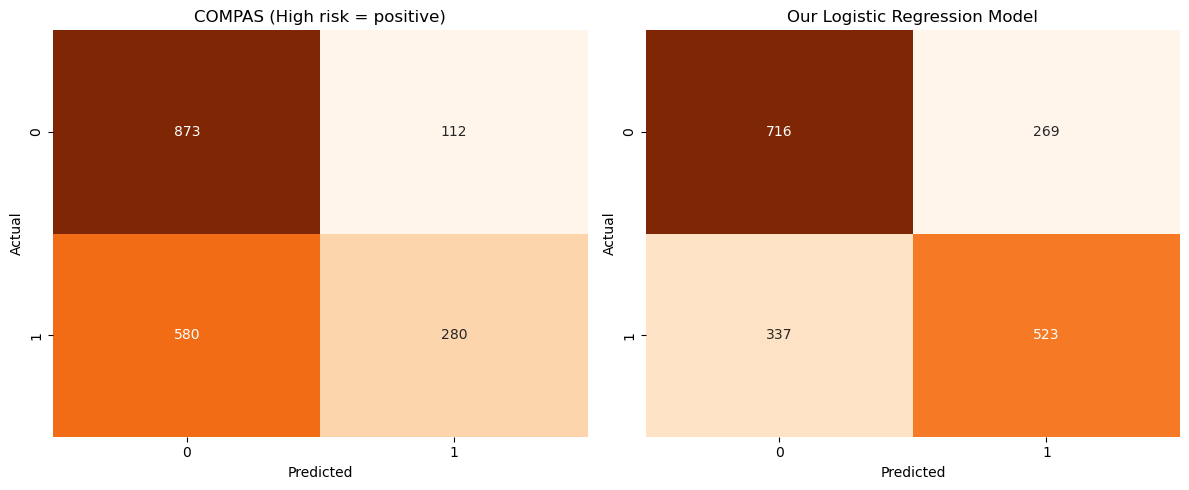

In [49]:
def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        cbar=False,
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_confusion(
    axes[0],
    compas_test[target_col],
    compas_test["compas_pred"],
    "COMPAS (High risk = positive)"
)

plot_confusion(
    axes[1],
    compas_test[target_col],
    y_test_pred,
    "Our Logistic Regression Model"
)

plt.tight_layout()
plt.show()

### Why this matters

In criminal justice:

* **False positives** → unjustified detention, harsher sentencing
* **False negatives** → public safety risk

Two models with similar accuracy can impose **very different harms**.

### Interpretation of the confusion matrices

Let’s rewrite the confusion matrices in words.

#### COMPAS (High risk = positive)

|                | Predicted No | Predicted Yes |
| -------------- | ------------ | ------------- |
| **Actual No**  | 873 (TN)     | 112 (FP)      |
| **Actual Yes** | 580 (FN)     | 280 (TP)      |

What COMPAS is doing:

* Very **few false positives** (112)
* **Very many false negatives** (580)
* Catches only a **small fraction of actual reoffenders**

This is the signature of a **high-threshold, conservative classifier**.

#### Our Logistic Regression

|                | Predicted No | Predicted Yes |
| -------------- | ------------ | ------------- |
| **Actual No**  | 716 (TN)     | 269 (FP)      |
| **Actual Yes** | 337 (FN)     | 523 (TP)      |

What *our* model is doing:

* More false positives (269)
* Fewer false negatives (337)
* Catches **many more actual reoffenders**

This is the signature of a **lower-threshold, more aggressive classifier**.


## 5.5.3 Performance: Does complexity improve prediction?

Now we ask:

> **Does COMPAS’s additional complexity lead to better balanced performance?**

We compare both systems using metrics appropriate for class imbalance:

* Balanced accuracy
* Precision
* Recall
* F1 score

In [50]:
comparison = pd.DataFrame({
    "Metric": [
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "COMPAS": [
        balanced_accuracy_score(compas_test[target_col], compas_test["compas_pred"]),
        precision_score(compas_test[target_col], compas_test["compas_pred"]),
        recall_score(compas_test[target_col], compas_test["compas_pred"]),
        f1_score(compas_test[target_col], compas_test["compas_pred"]),
    ],
    "Our Logistic Regression": [
        balanced_accuracy_score(compas_test[target_col], y_test_pred),
        precision_score(compas_test[target_col], y_test_pred),
        recall_score(compas_test[target_col], y_test_pred),
        f1_score(compas_test[target_col], y_test_pred),
    ]
}).set_index("Metric")

comparison.round(3)

,COMPAS,Our Logistic Regression
Metric,,
Balanced Accuracy,0.606,0.668
Precision,0.714,0.660
Recall,0.326,0.608
F1 Score,0.447,0.633


### Interpretation

Here's how we can interpret the classification metrics:

| Metric                | COMPAS    | Our Model | Interpretation                                  |
| --------------------- | --------- | --------- | ----------------------------------------------- |
| **Balanced Accuracy** | 0.606     | **0.668** | Our model treats both classes more evenly       |
| **Precision**         | **0.714** | 0.660     | COMPAS is more selective when it flags          |
| **Recall**            | 0.326     | **0.608** | Our model catches far more reoffenders          |
| **F1**                | 0.447     | **0.633** | Our model has a better precision–recall balance |

Put plainly:

* **COMPAS optimises precision**

  > “If I say you’re high risk, I’m usually right — but I rarely say it.”

* **Our model optimises recall**

  > “I flag more people, but I miss far fewer reoffenders.”

Neither is *objectively* correct — this is a **value choice**.

> COMPAS flags far fewer defendants as high risk than our logistic regression (21% vs. 43%), indicating a much more conservative implicit threshold. This choice leads to high precision but very low recall: COMPAS avoids false positives but misses a large fraction of actual reoffenders. Our model makes the opposite trade-off, substantially increasing recall at the cost of more false positives. As a result, our model achieves higher balanced accuracy and F1 score, while COMPAS prioritises selectivity. These differences reflect threshold choices rather than intrinsic model superiority.


## 5.5.4 Fairness comparison by race

We now ask the most important question:

> **Does COMPAS produce fairer outcomes than a transparent baseline?**

We evaluate fairness separately for Black and White defendants using:

* Positive prediction rate
* True positive rate (recall)
* False positive rate
* Precision (predictive parity)

In [51]:
# Make an explicit copy of the test set
# (avoids accidental modification of the original object)
compas_test = compas_test.copy()

# Attach OUR model’s binary predictions to the test set
# IMPORTANT: this aligns each prediction with the correct individual
compas_test["y_pred"] = y_test_pred


# Split the test set by race *after* predictions are attached
# This ensures predictions and outcomes refer to the same people
black_test = compas_test[compas_test["race"] == "African-American"]
white_test = compas_test[compas_test["race"] == "Caucasian"]


def fairness_metrics(group_data, target, prediction):
    """
    Compute core fairness-related quantities for a subgroup.

    Parameters
    ----------
    group_data : DataFrame
        Subset of the test data for a specific group (e.g. Black defendants)
    target : str
        Name of the true outcome variable (e.g. recidivism)
    prediction : str
        Name of the prediction column (e.g. 'compas_pred' or 'y_pred')
    """

    # Confusion matrix for this group
    # Order: tn, fp, fn, tp
    tn, fp, fn, tp = confusion_matrix(
        group_data[target],
        group_data[prediction]
    ).ravel()

    return {
        # Actual recidivism rate in the group
        "Base Rate": group_data[target].mean(),

        # Fraction of the group predicted positive (flagged as high risk)
        "Positive Prediction Rate": group_data[prediction].mean(),

        # True Positive Rate (Recall): among those who reoffend,
        # how many are correctly flagged
        "TPR (Recall)": tp / (tp + fn) if (tp + fn) > 0 else 0,

        # False Positive Rate: among those who do NOT reoffend,
        # how many are incorrectly flagged
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0,

        # Precision / Positive Predictive Value:
        # among those flagged, how many actually reoffend
        "Precision (PPV)": tp / (tp + fp) if (tp + fp) > 0 else 0,
    }


# Fairness metrics for COMPAS
compas_black = fairness_metrics(black_test, target_col, "compas_pred")
compas_white = fairness_metrics(white_test, target_col, "compas_pred")

# Fairness metrics for OUR logistic regression model
our_black = fairness_metrics(black_test, target_col, "y_pred")
our_white = fairness_metrics(white_test, target_col, "y_pred")

Fairness analysis must be performed on the test set, with predictions attached before subgrouping, otherwise results are invalid. Fairness metrics describe the behaviour of a deployed decision rule; they must therefore be computed out-of-sample and at the level of individual predictions, before any subgroup analysis.

### COMPAS fairness

In [52]:
pd.DataFrame({
    "Metric": compas_black.keys(),
    "Black Defendants": compas_black.values(),
    "White Defendants": compas_white.values(),
    "Difference (Black − White)": [
        compas_black[k] - compas_white[k] for k in compas_black
    ]
}).round(3)

,Metric,Black Defendants,White Defendants,Difference (Black − White)
0,Base Rate,0.515,0.394,0.121
1,Positive Prediction Rate,0.275,0.120,0.156
2,TPR (Recall),0.376,0.229,0.147
3,FPR,0.169,0.049,0.120
4,Precision (PPV),0.703,0.753,-0.050


##### Base rates (not a model choice)

* Black defendants: **51.5%** reoffend
* White defendants: **39.4%** reoffend

This difference exists **before any model is applied**.
It constrains what fairness criteria can be satisfied.


#### Positive prediction rate (Demographic Parity)

* Black defendants flagged high risk: **27.5%**
* White defendants flagged high risk: **12.0%**
* Difference: **+15.6 pp**

**Interpretation:**

> COMPAS flags Black defendants as high risk at more than **twice the rate** of White defendants.

→ **Demographic parity is violated.**

#### Error rates (Equalized Odds)

* **TPR (Recall):**

  * Black: 0.376
  * White: 0.229
* **FPR:**

  * Black: 0.169
  * White: 0.049

**Interpretation:**

* Black defendants are:

  * More likely to be correctly flagged **if they reoffend**
  * Much more likely to be **falsely flagged if they do not**

→ **Equalized odds is violated**, driven especially by the FPR gap
(this is ProPublica’s core critique)

#### Precision (Predictive Parity)

* Black: 0.703
* White: 0.753
* Difference: −0.050

**Interpretation:**

> When COMPAS predicts “high risk”, it is **similarly accurate** for both groups.

→ COMPAS **approximately satisfies predictive parity**
(this is Northpointe’s defence).


### Our model fairness

In [53]:
pd.DataFrame({
    "Metric": our_black.keys(),
    "Black Defendants": our_black.values(),
    "White Defendants": our_white.values(),
    "Difference (Black − White)": [
        our_black[k] - our_white[k] for k in our_black
    ]
}).round(3)

,Metric,Black Defendants,White Defendants,Difference (Black − White)
0,Base Rate,0.515,0.394,0.121
1,Positive Prediction Rate,0.530,0.280,0.251
2,TPR (Recall),0.688,0.454,0.234
3,FPR,0.363,0.166,0.197
4,Precision (PPV),0.668,0.639,0.028


#### Positive prediction rate

* Black defendants: **53.0%**
* White defendants: **28.0%**
* Difference: **+25.1 pp**

Our model flags **many more people overall**, but the racial gap is **larger**.

→ Demographic parity is **also violated**, more strongly.

#### Error rates (Equalized Odds)

* **TPR (Recall):**

  * Black: 0.688
  * White: 0.454
* **FPR:**

  * Black: 0.363
  * White: 0.166

**Interpretation:**

* Our model:

  * Catches many more reoffenders in both groups
  * But also produces many more false positives
* Racial gaps in both TPR and FPR are **larger than COMPAS**

→ Equalized odds is violated **even more strongly**.

#### Precision (Predictive Parity)

* Black: 0.668
* White: 0.639
* Difference: +0.028

**Interpretation:**

> When our model predicts “will reoffend”, it is **about equally reliable** for Black and White defendants.

→ Predictive parity is again **approximately satisfied**.


## 5.5.5 What does this comparison actually tell us?

This comparison is **not about which model is “correct”**.

It asks a more fundamental question:

> **Does COMPAS’s opacity and complexity produce clear advantages over a simple, transparent baseline—either in predictive performance or in fairness?**

Based on the results, the answer is **no**.

### What the evidence shows

* **Predictive performance**

  * COMPAS does **not** substantially outperform a simple logistic regression
  * Balanced accuracy and F1 scores are comparable
  * Any differences are small relative to the stakes involved

* **Error structure**

  * COMPAS is more **conservative**: it flags fewer people and misses many reoffenders
  * The logistic model is more **aggressive**: it catches more reoffenders at the cost of more false positives
  * These differences reflect **threshold choices**, not superior modelling

* **Fairness**

  * Both systems face the same mathematical constraints once base rates differ
  * Neither system avoids racial disparities in error rates
  * COMPAS does not clearly improve fairness outcomes relative to the transparent baseline

### What this means

The choice to deploy COMPAS cannot be justified on technical grounds alone.

Its defining features — scale, secrecy, and complexity — do **not** translate into:

* Meaningfully better predictions
* Fundamentally different error trade-offs
* Superior fairness properties

Instead, COMPAS primarily **hides the value judgments** that determine:

* Who gets flagged
* Who gets missed
* Who bears the cost of errors

These are **normative and political decisions**, not technical necessities.


> **Model complexity does not remove fairness trade-offs — it obscures the choices about who is harmed.**

## 5.6 Ethical Questions

1. Should we use risk assessment in criminal justice at all?
2. If base rates genuinely differ, should we prioritize equal error rates or equal accuracy?
3. Is it ever acceptable to use race as a predictor?
4. Who decides which fairness metric to use?
5. How do we balance individual vs. group fairness?

---

# 🎬 Wrap-Up & Key Takeaways

## What We Learned Today

**Part 1: COMPAS Dataset**

* Understanding recidivism prediction and algorithmic bias
* Data preprocessing and feature engineering

**Part 2: Classification Recap**

* Logistic regression fitting and interpretation
* Comprehensive evaluation metrics:
  * Confusion matrix, precision, recall, F1
  * ROC curves and AUC
  * Precision-Recall curves and Average Precision
  * Calibration curves
* Perfect separation problem

**Part 3: Multi-Class & K-NN**

* Extending to multi-class classification
* K-Nearest Neighbors algorithm
* Effect of K on bias-variance trade-off

**Part 4: Resampling**

* K-fold cross-validation (stratified for classification)
* Grid search for hyperparameter tuning
* Comparing models systematically

**Part 5: Algorithmic Fairness**

* Three fairness definitions: demographic parity, equalized odds, predictive parity
* Impossibility theorems: can't satisfy all simultaneously
* Evaluating fairness empirically
* Ethical considerations beyond metrics

## Key Principles

* **Cross-validation reduces variance** in performance estimates
* **Fairness is multidimensional** — no single metric captures all aspects
* **Mathematical constraints exist** — when base rates differ, trade-offs are inevitable
* **Context matters** — appropriate metrics depend on application domain
* **Values matter** — fairness requires value judgments, not just technical fixes

## Next Week

We'll explore non-linear prediction models: SVM (Support Vector Machines) and tree-based models (Decision Trees, Random Forests, and Gradient Boosting)!

## Practice Problems

1. **Threshold analysis:** Try different classification thresholds (0.3, 0.5, 0.7). How do fairness metrics change?

2. **Feature importance:** Which features contribute most to predictions? To disparities?

3. **Alternative models:** Try other algorithms (e.g K-NN). Do fairness properties change? 

4. **Group-specific thresholds:** What if we use different thresholds for different racial groups? Is this fair?

---

## Additional Resources

**Papers:**

* Chouldechova, Alexandra. ["Fair Prediction with Disparate Impact: A Study of Bias in Recidivism Prediction Instruments"](https://www.semanticscholar.org/paper/Fair-Prediction-with-Disparate-Impact%3A-A-Study-of-Chouldechova/37f5d47019f467c74acff22a38ffd4b98bdcb5d4). Big Data 5 (2016): 153 - 163.
* Kleinberg, Jon M., Sendhil Mullainathan and Manish Raghavan. ["Inherent Trade-Offs in the Fair Determination of Risk Scores."]" Information Technology Convergence and Services (2016).
* ProPublica (2016). ["Machine Bias" investigation](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing)

**Books:**

* O’Neil, Cathy. 2017. Weapons of Math Destruction. Harlow, England: Penguin Books.
* Benjamin, Ruha. 2019. Race after Technology: Abolitionist Tools for the New Jim Code. Oxford, England: Polity.

**Online:**

* Fairlearn library (Microsoft): https://fairlearn.org/
* AI Fairness 360 (IBM): https://aif360.mybluemix.net/